Importing datasets from GoogleDrive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Installing ultralytics to get YOLO model

In [2]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.8 MB/s eta 0:00:00


Importing libraries

In [20]:
import matplotlib.pyplot as plt
import shutil
from ultralytics import YOLO
import os
import sys
import cv2
from google.colab.patches import cv2_imshow
import pandas as pd

project_dir = '/content/drive/MyDrive/Hand_Gesture_Project'
sys.path.append(project_dir)

from utils.split_object_detection import split_od_dataset

Getting the dataset for object detection

In [4]:
data_zip_path = os.path.join(project_dir, 'data/data.zip')
!unzip {data_zip_path} -d /content/data

Archive:  /content/drive/MyDrive/Hand_Gesture_Project/data/data.zip
   creating: /content/data/dataset_classification/
   creating: /content/data/dataset_classification/0/
  inflating: /content/data/dataset_classification/0/img_onlyhand_001-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_007-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_013-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_019-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_025-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_031-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_037-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_043-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_049-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhan

Defining the paths for images folder, labels folder and output folder

In [5]:
images_dir = "/content/data/dataset_object_detection/images"
labels_dir = "/content/data/dataset_object_detection/labels"
output_dir = "/content/data/dataset_object_detection_split"

Optional line (to delete the split and start over)

In [ ]:
!rm -r /content/data/dataset_object_detection_split

Calling split function on dataset_object_detection dataset

In [6]:
split_od_dataset(
    images_dir=images_dir,
    labels_dir=labels_dir,
    output_dir=output_dir,
    train_ratio=0.7,  # 70% train
    val_ratio=0.2     # 20% validation, the rest 10% for test
)

Found onlyhand images: 222
Found selfie images: 222

Distribution after splitting:
train: onlyhand=155, selfie=155 (total 310)
val: onlyhand=44, selfie=44 (total 88)
test: onlyhand=23, selfie=23 (total 46)


Model creation

In [7]:
model = YOLO("yolo11n.pt")

Path to the YOLO model configuration

In [8]:
yaml_path = os.path.join(project_dir, 'configuration/detection.yaml')

Training of the model

In [9]:
model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=15,          # early stopping
    project="runs",
    name="hand_yolo11",
    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,        # cosine learning rate
    amp=True            # mixed precision
)


Ultralytics 8.3.245 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Hand_Gesture_Project/configuration/detection.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=hand_yolo11, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, 

KeyboardInterrupt: 

Saving the best model and last one for inference stage in the future

In [ ]:
models_dir = os.path.join(project_dir, 'models/detection')
os.makedirs(models_dir, exist_ok=True)

# Saving the best model
shutil.copy('/content/runs/hand_yolo11/weights/best.pt', os.path.join(models_dir, 'hand_detector_best.pt'))

# Also saving the last one (just in case)
shutil.copy('/content/runs/hand_yolo11/weights/last.pt', os.path.join(models_dir, 'hand_detector_last.pt'))

'/content/drive/MyDrive/Hand_Gesture_Project/models/detection/hand_detector_last1.pt'

Testing the model

In [10]:
model_save_path = os.path.join(project_dir, 'models/detection/hand_detector_best.pt')
model = YOLO(model_save_path)

Metrics on test split

In [11]:
metrics = model.val(data=yaml_path, split="test")

Ultralytics 8.3.245 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3278.7±1434.6 MB/s, size: 358.4 KB)
val: Scanning /content/data/dataset_object_detection_split/test/labels... 46 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 2.0Kit/s 0.0s
val: New cache created: /content/data/dataset_object_detection_split/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4s/it 4.3s
                   all         46         46      0.998          1      0.995      0.994
Speed: 2.3ms preprocess, 18.8ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/val


Run this (before saving or checking results)

In [12]:
results_dir = os.path.join(project_dir, 'results/detection_metrics')
os.makedirs(results_dir, exist_ok=True)

Saving metrics of the best model on the training set and on the test set

In [ ]:
# Saving training results
shutil.copytree('/content/runs/hand_yolo11', os.path.join(results_dir, 'training_hand_yolo11'), dirs_exist_ok=True)

# Saving val/test results
shutil.copytree('/content/runs/detect/val', os.path.join(results_dir, 'val_test_metrics'), dirs_exist_ok=True)

'/content/drive/MyDrive/Hand_Gesture_Project/results/detection_metrics/val_test_metrics__2'

# Checking the results
Paths to the directories

In [21]:
# Paths to the directories
training_dir = os.path.join(results_dir, 'training_hand_yolo11')
test_dir = os.path.join(results_dir, 'val_test_metrics')

List of key plot files to display

In [22]:
# List of key plot files to display
key_plots = [
    'results.png',                    # Training loss curves and metrics over epochs (in training_dir)
    'BoxF1_curve.png',                # F1 curve for bounding boxes
    'BoxP_curve.png',                 # Precision curve
    'BoxPR_curve.png',                # Precision-Recall curve
    'BoxR_curve.png',                 # Recall curve
    'confusion_matrix.png',           # Confusion matrix
    'confusion_matrix_normalized.png' # Normalized confusion matrix (useful for class imbalance)
]

List of key plot files to display (matched to YOLO detection output names)


In [23]:
test_examples = [
    'val_batch0_labels.jpg', 'val_batch0_pred.jpg',
    'val_batch1_labels.jpg', 'val_batch1_pred.jpg',
    'val_batch2_labels.jpg', 'val_batch2_pred.jpg'
]

Display training plots

Training Results (from training_hand_yolo11):
Displaying results.png:


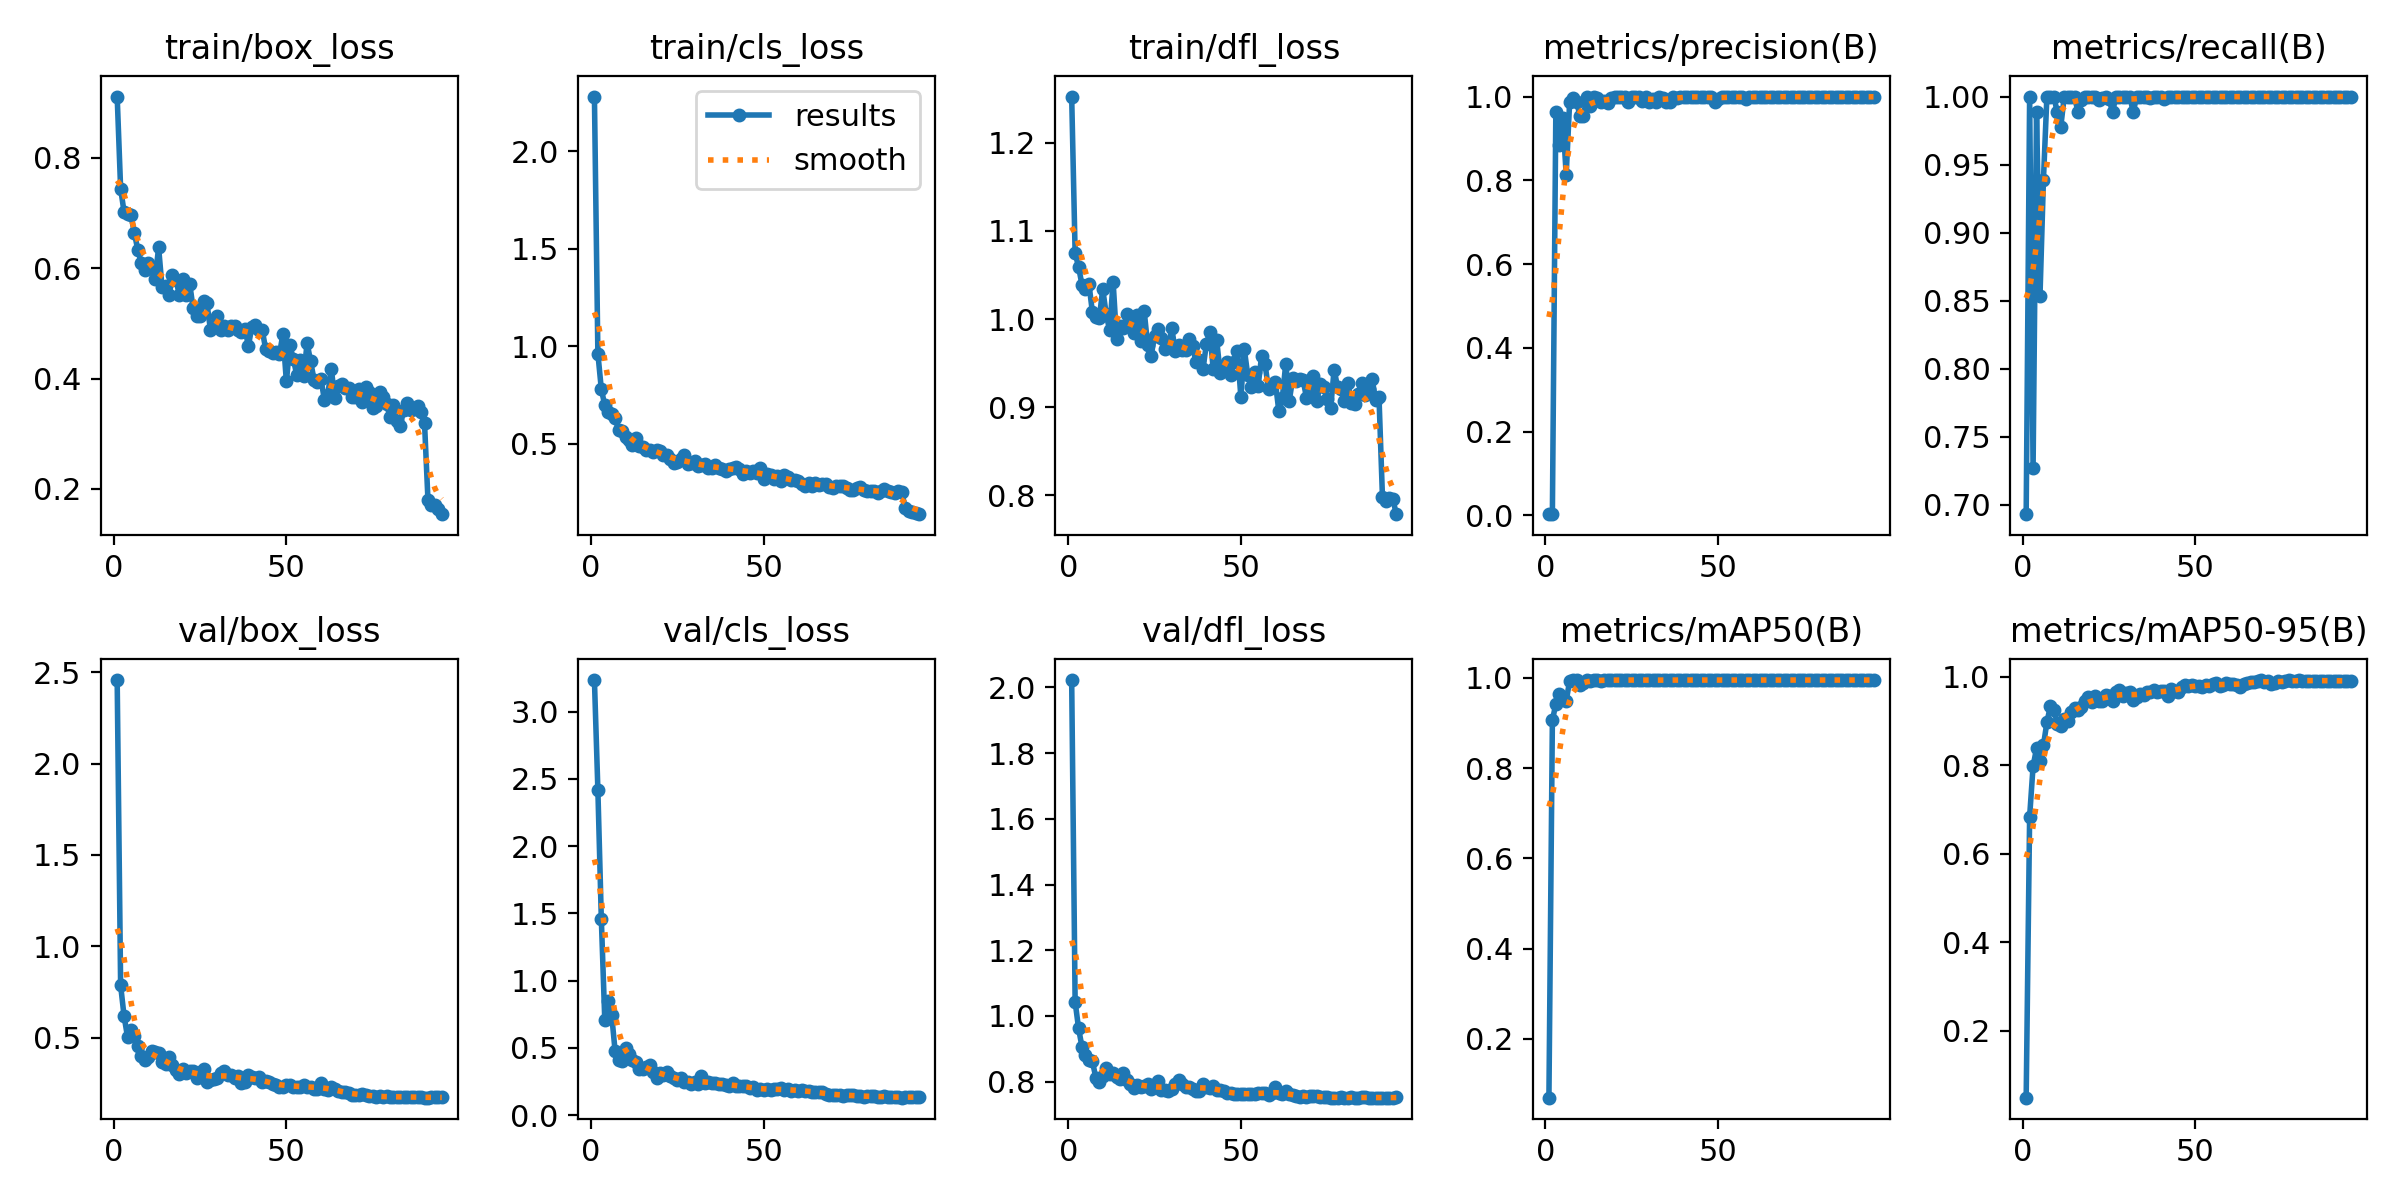

Displaying BoxF1_curve.png:


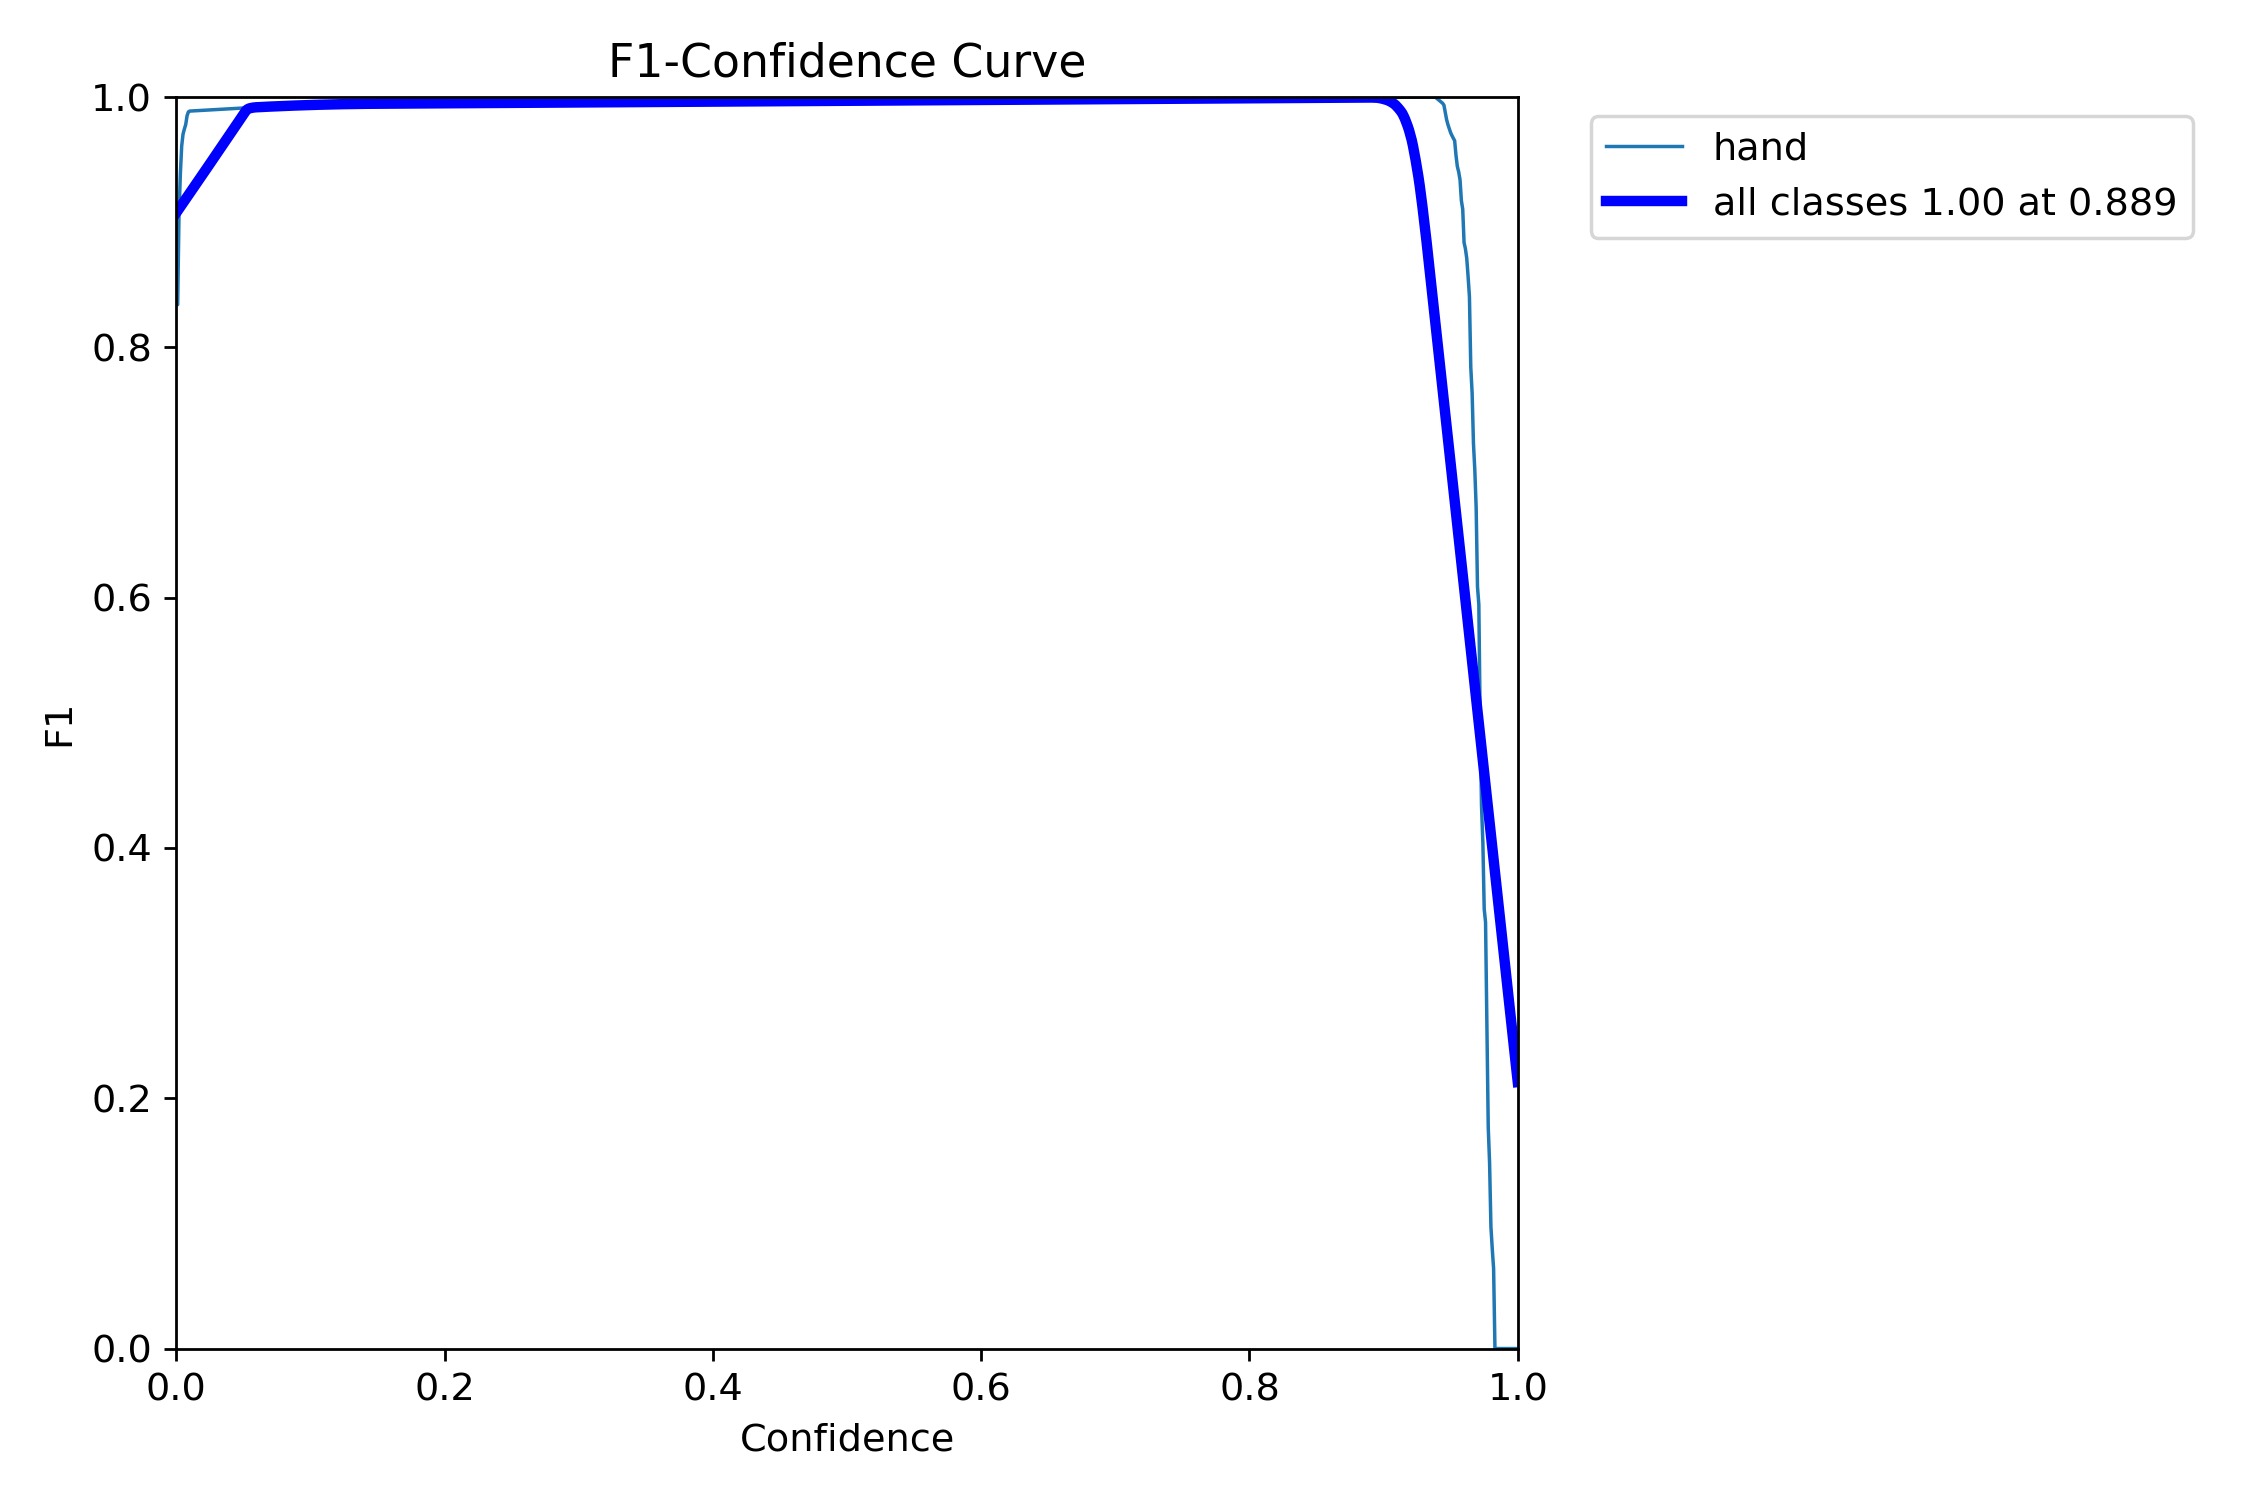

Displaying BoxP_curve.png:


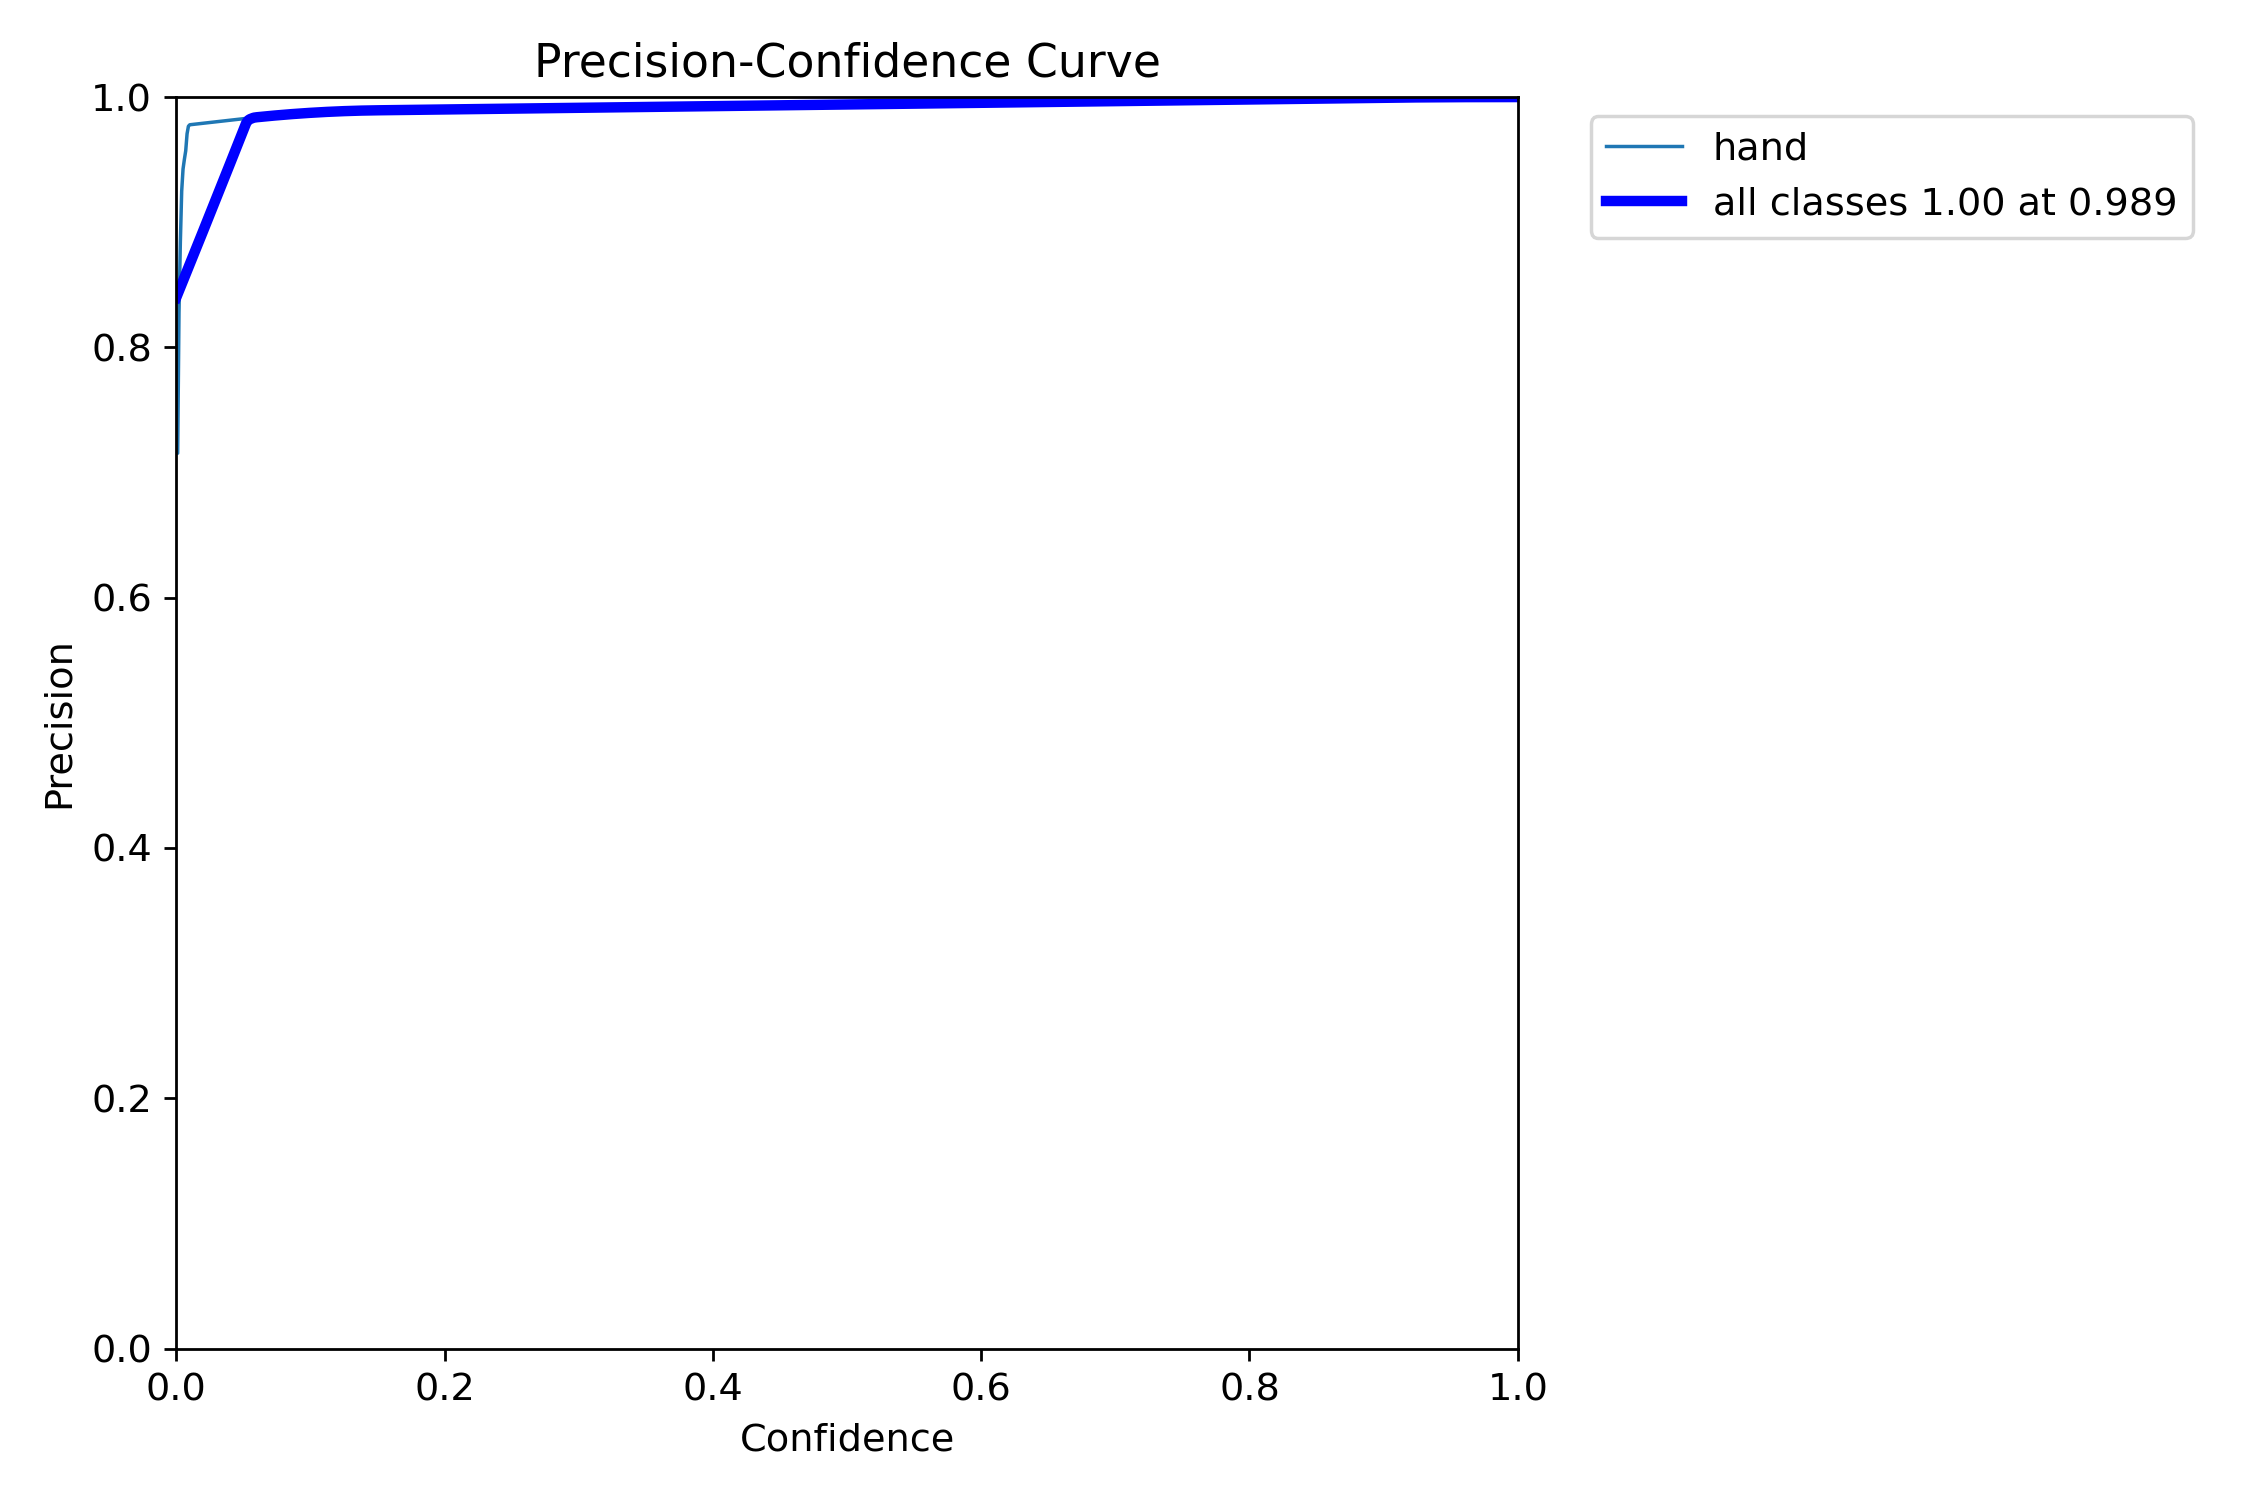

Displaying BoxPR_curve.png:


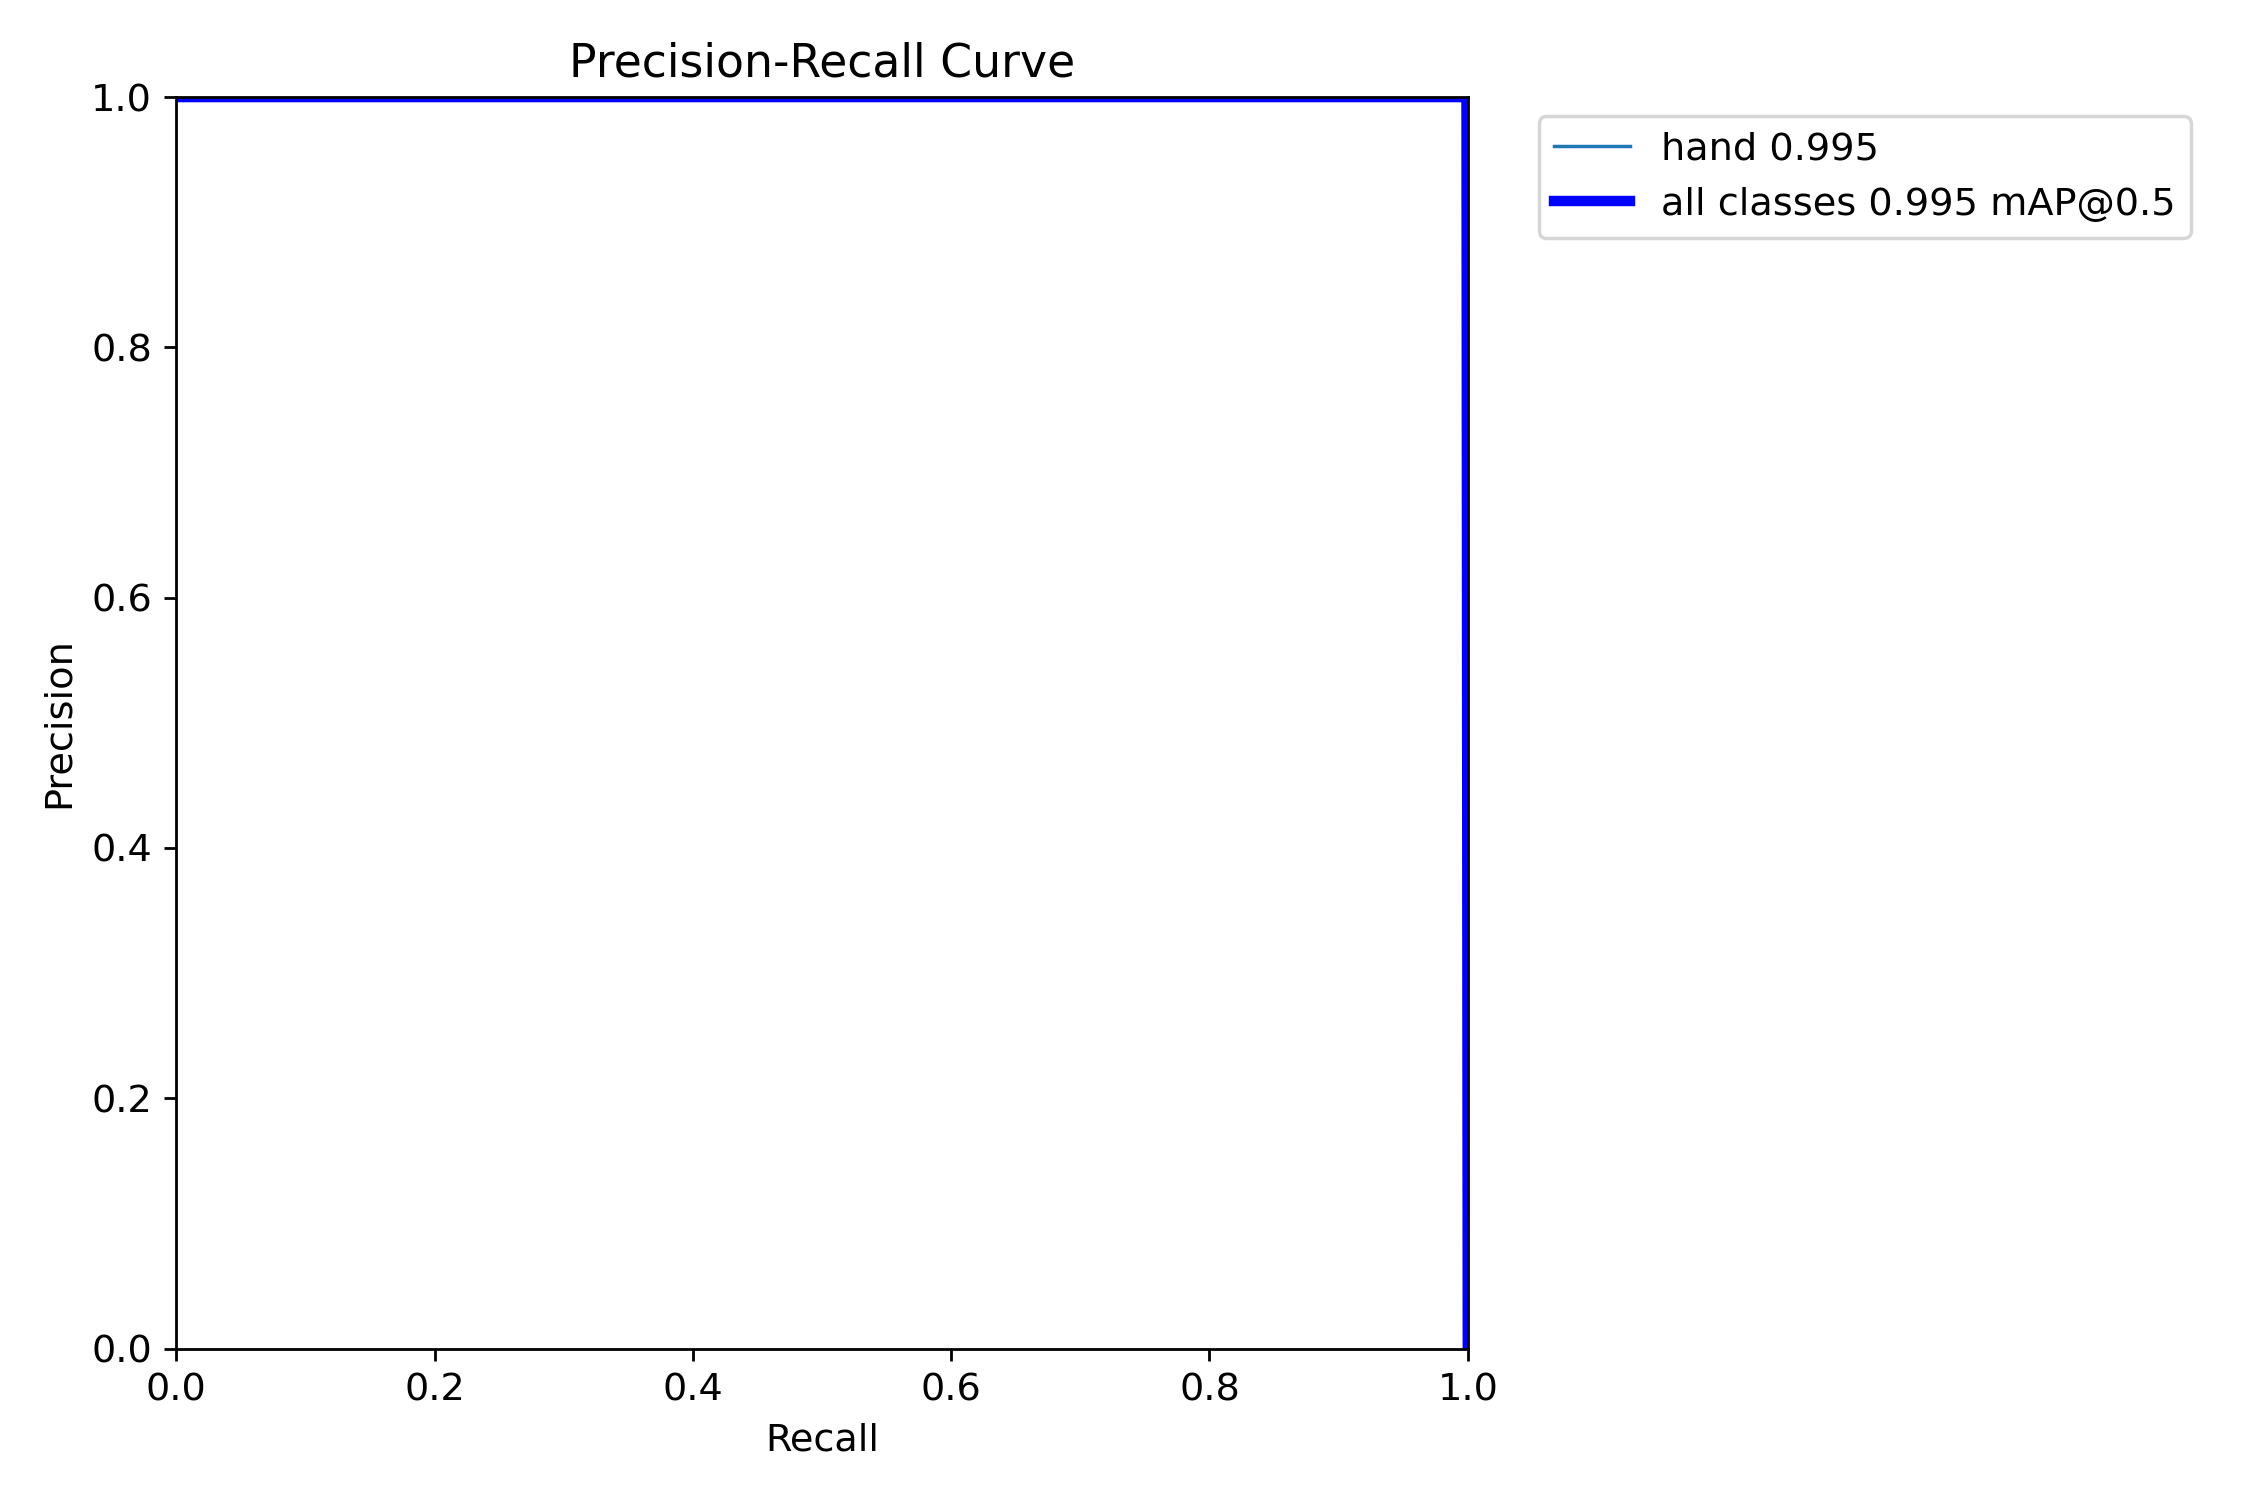

Displaying BoxR_curve.png:


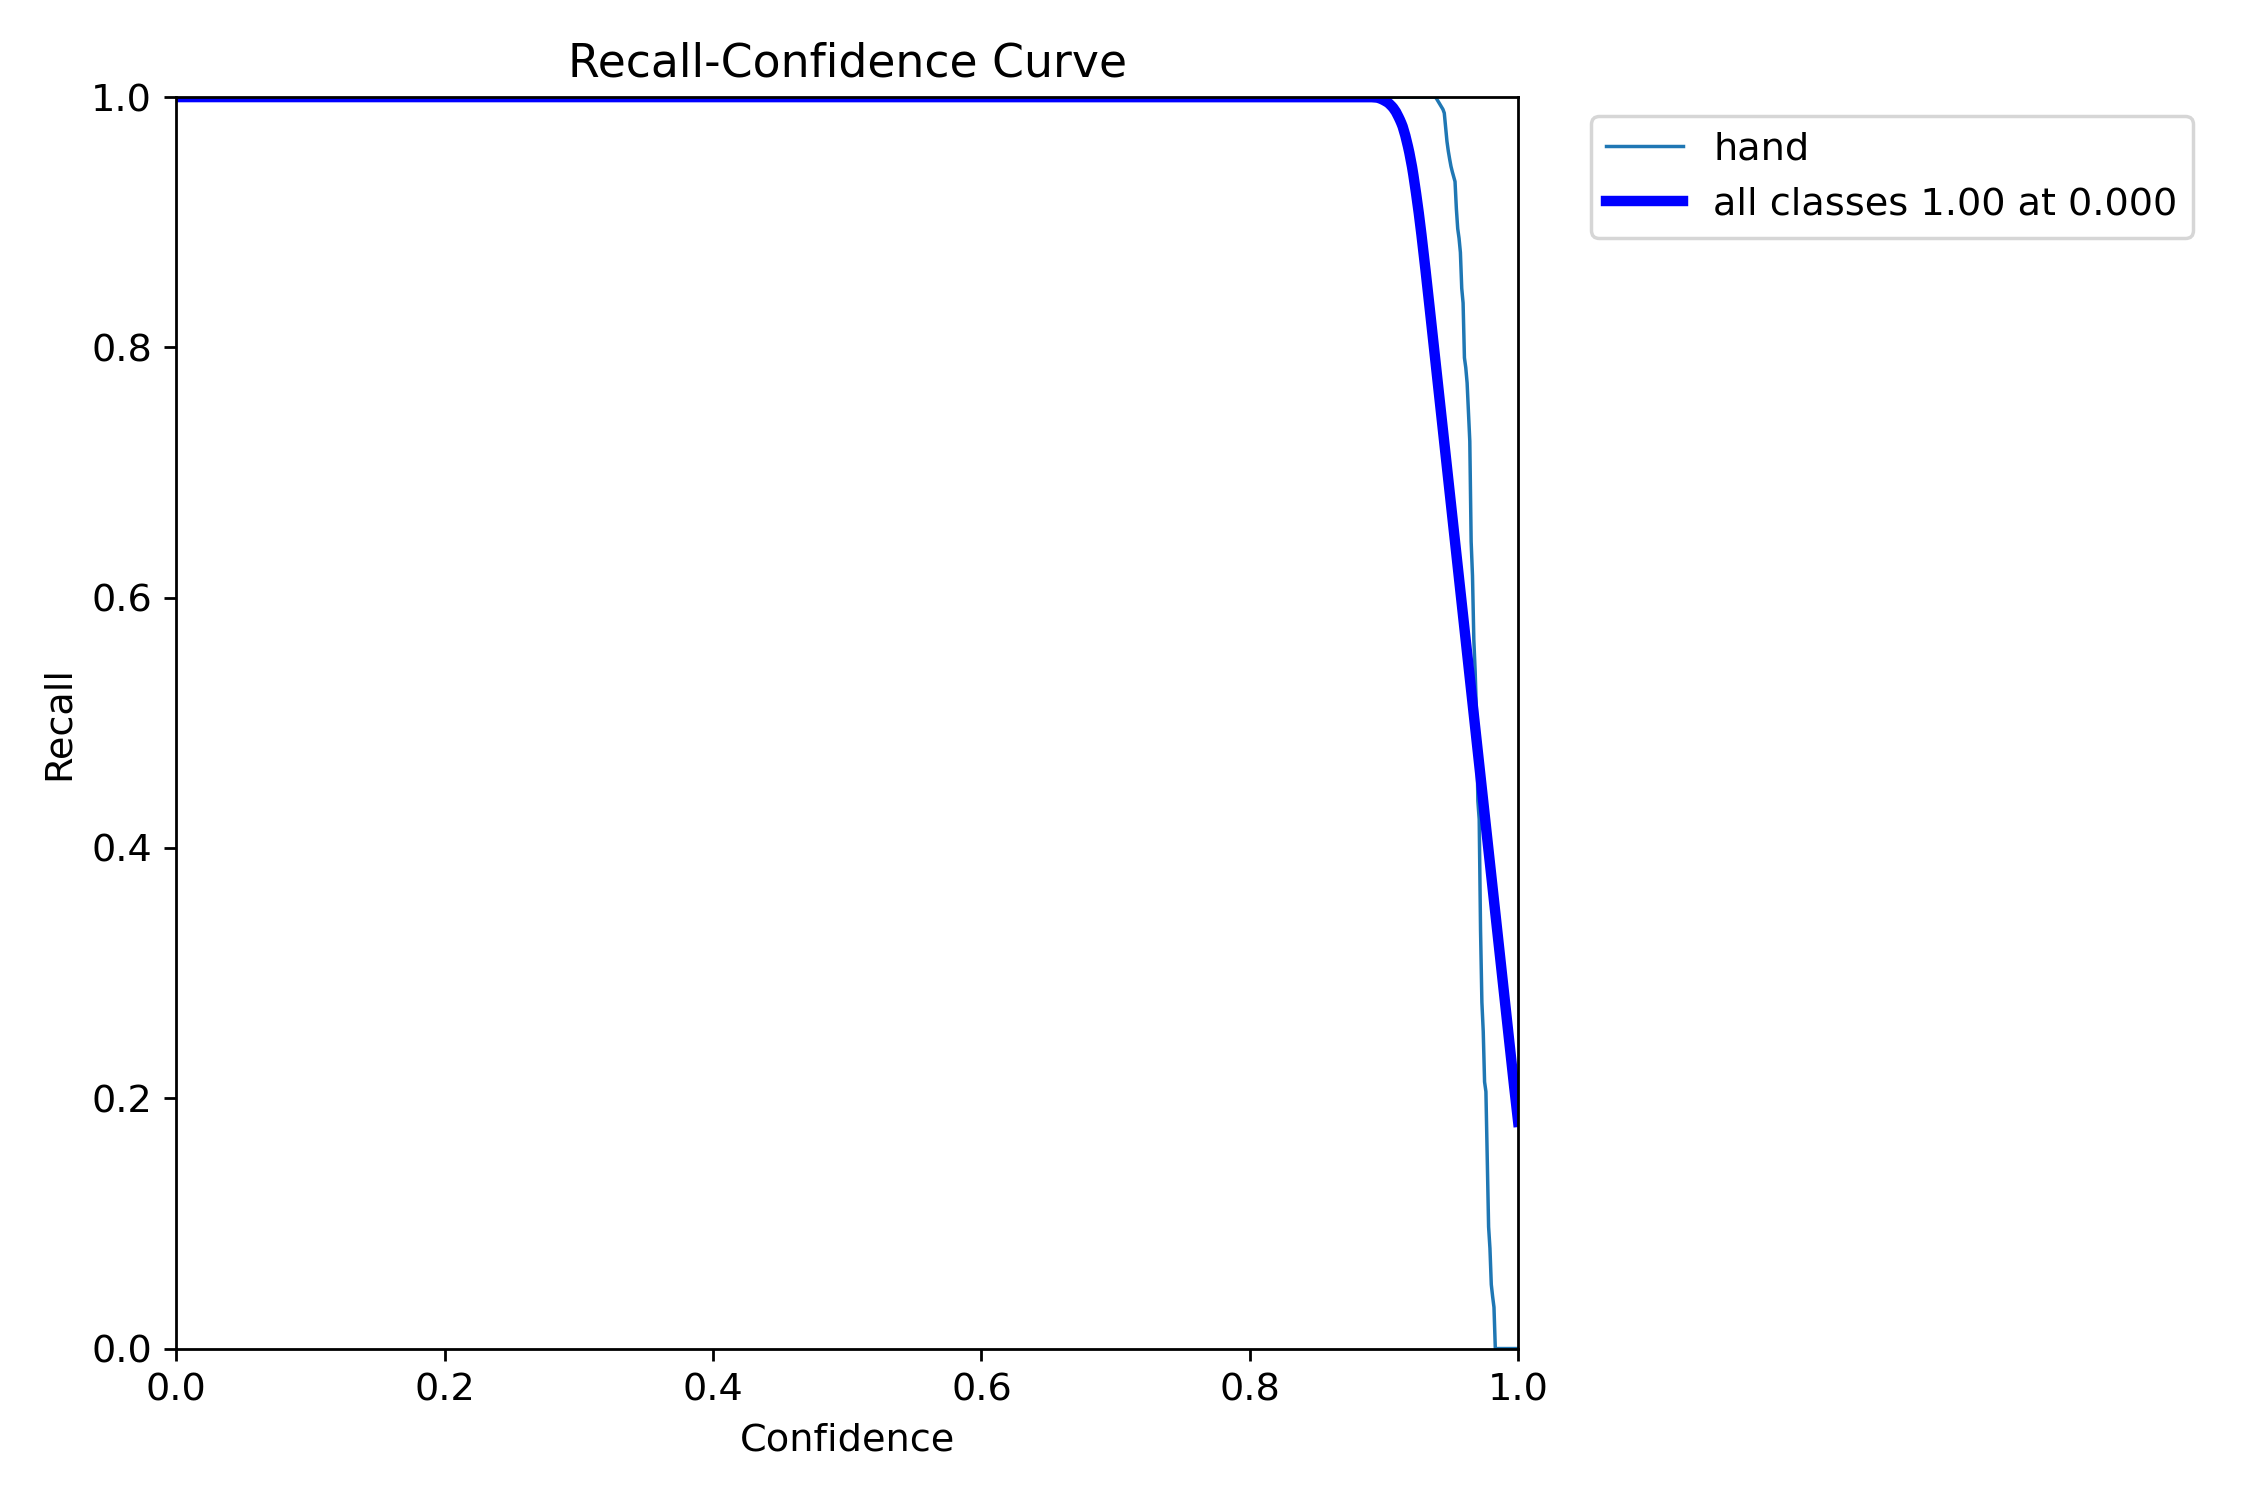

Displaying confusion_matrix.png:


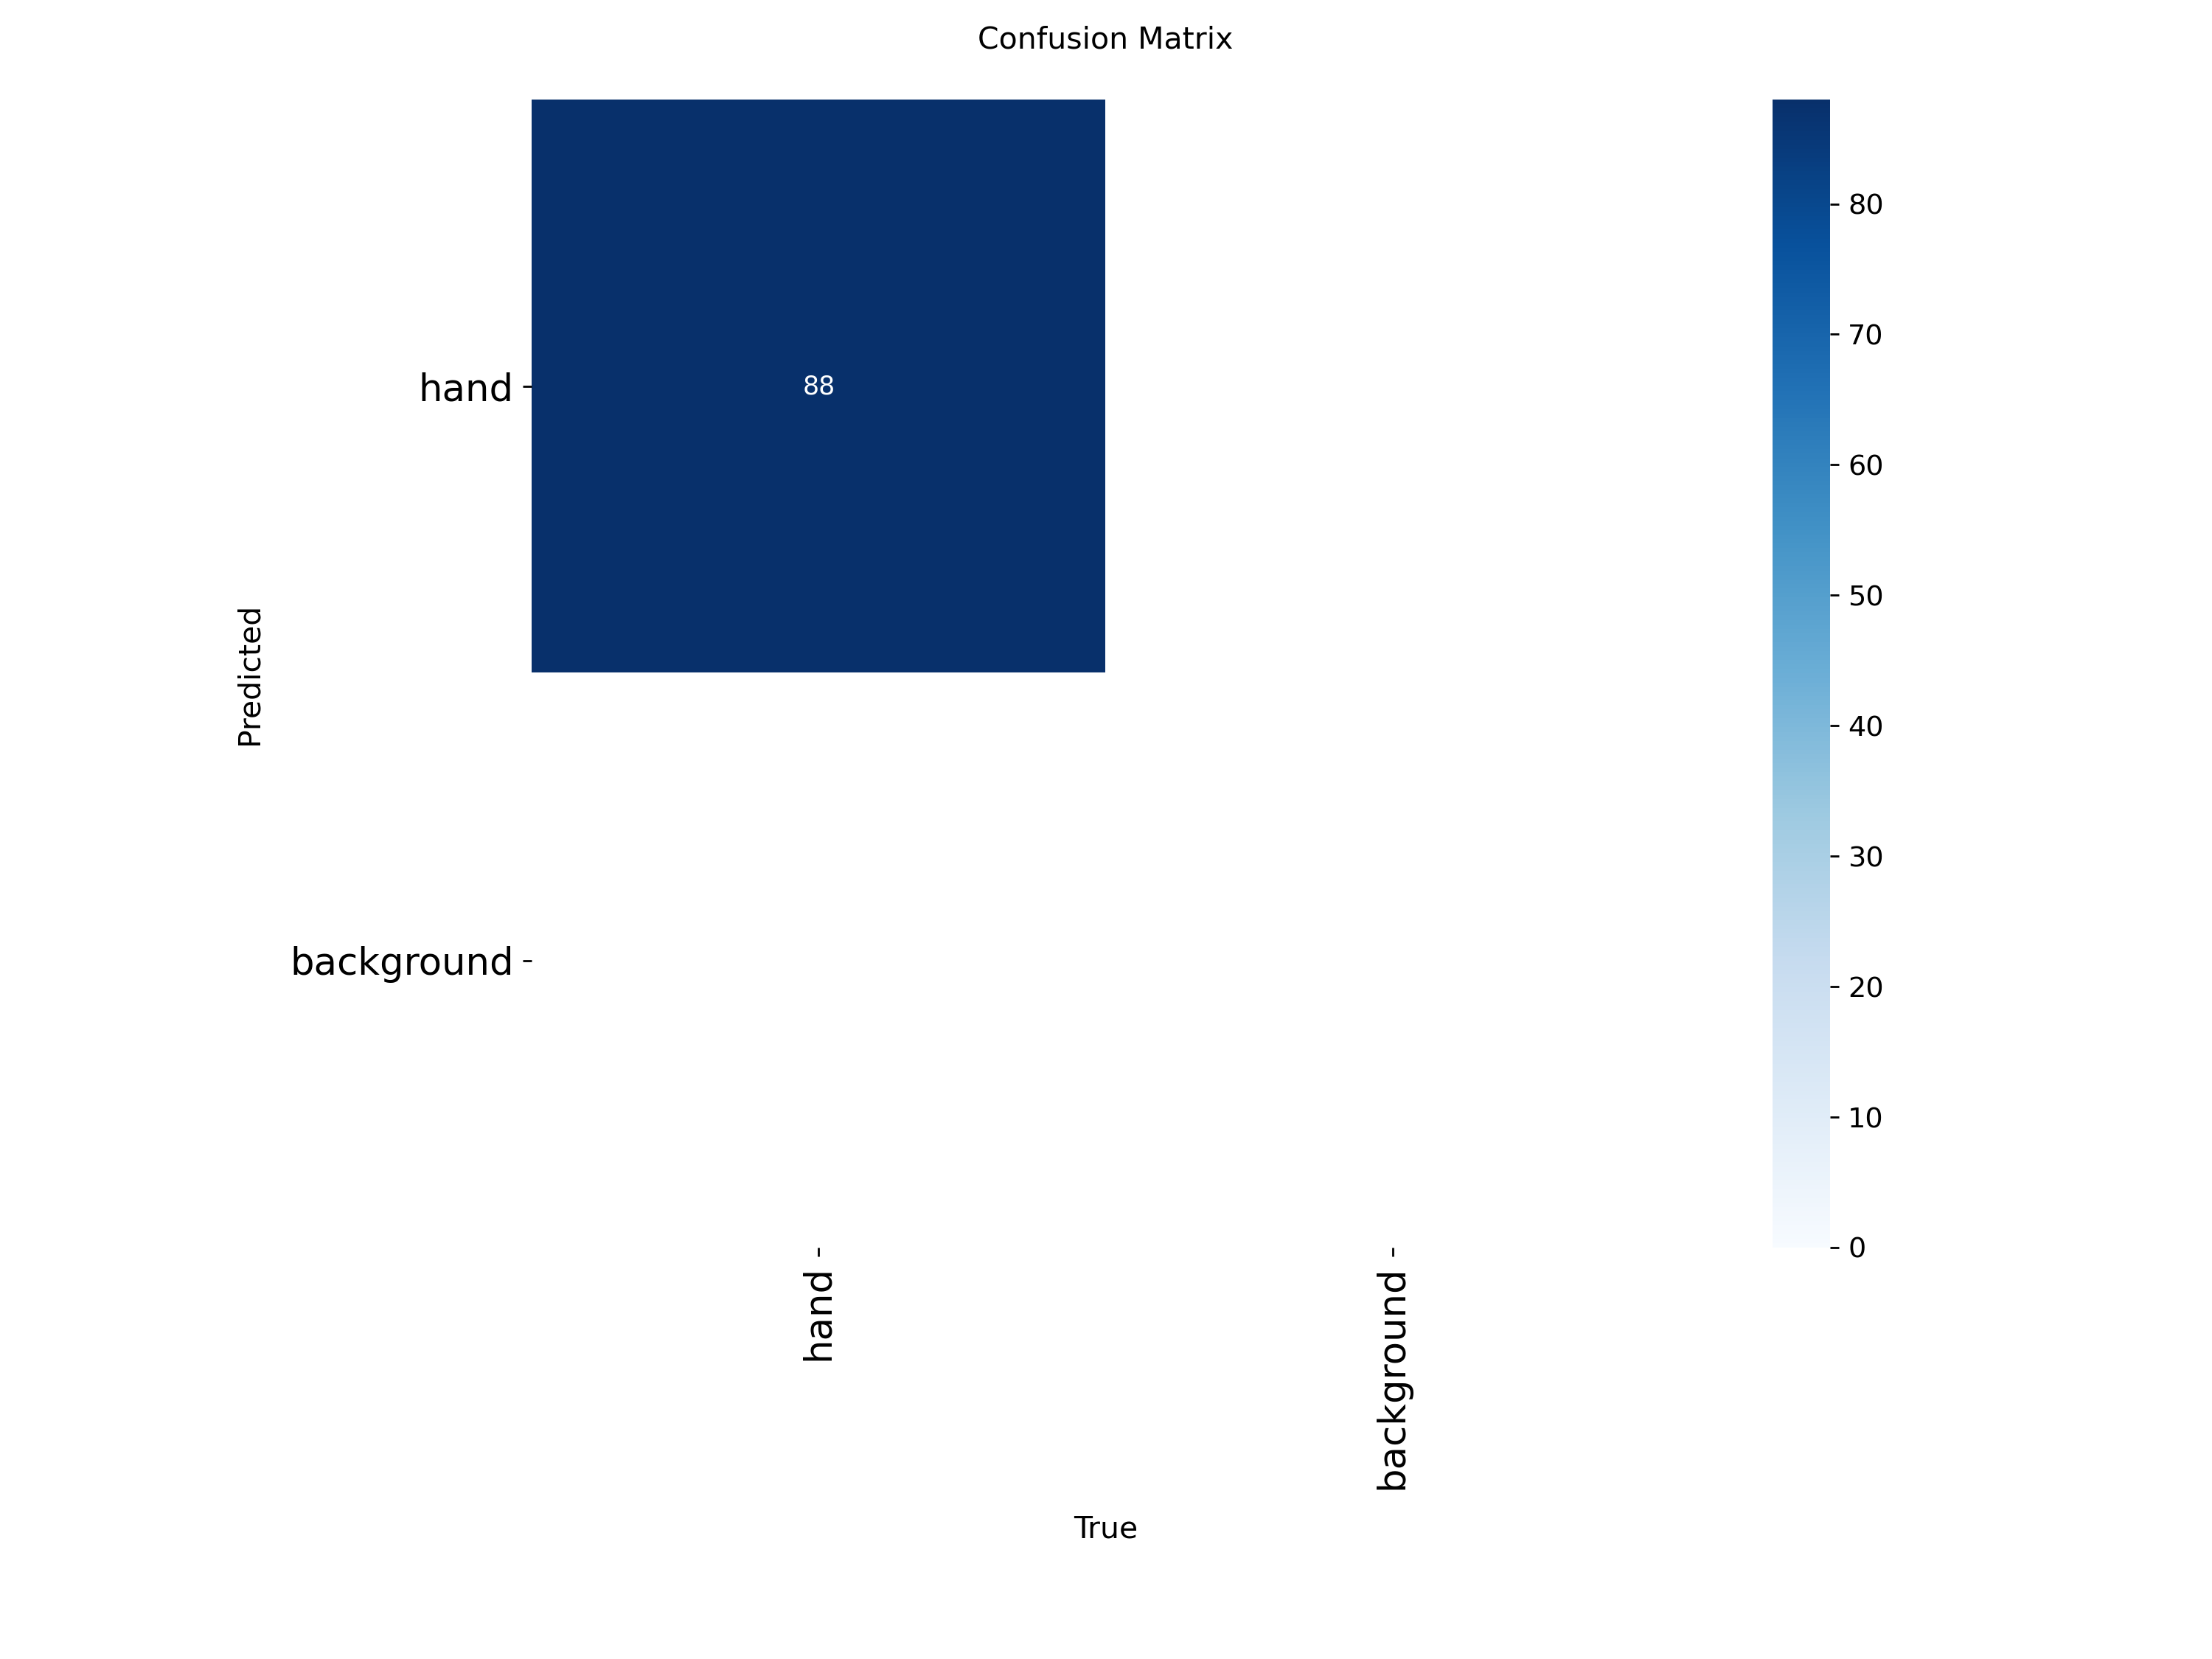

Displaying confusion_matrix_normalized.png:


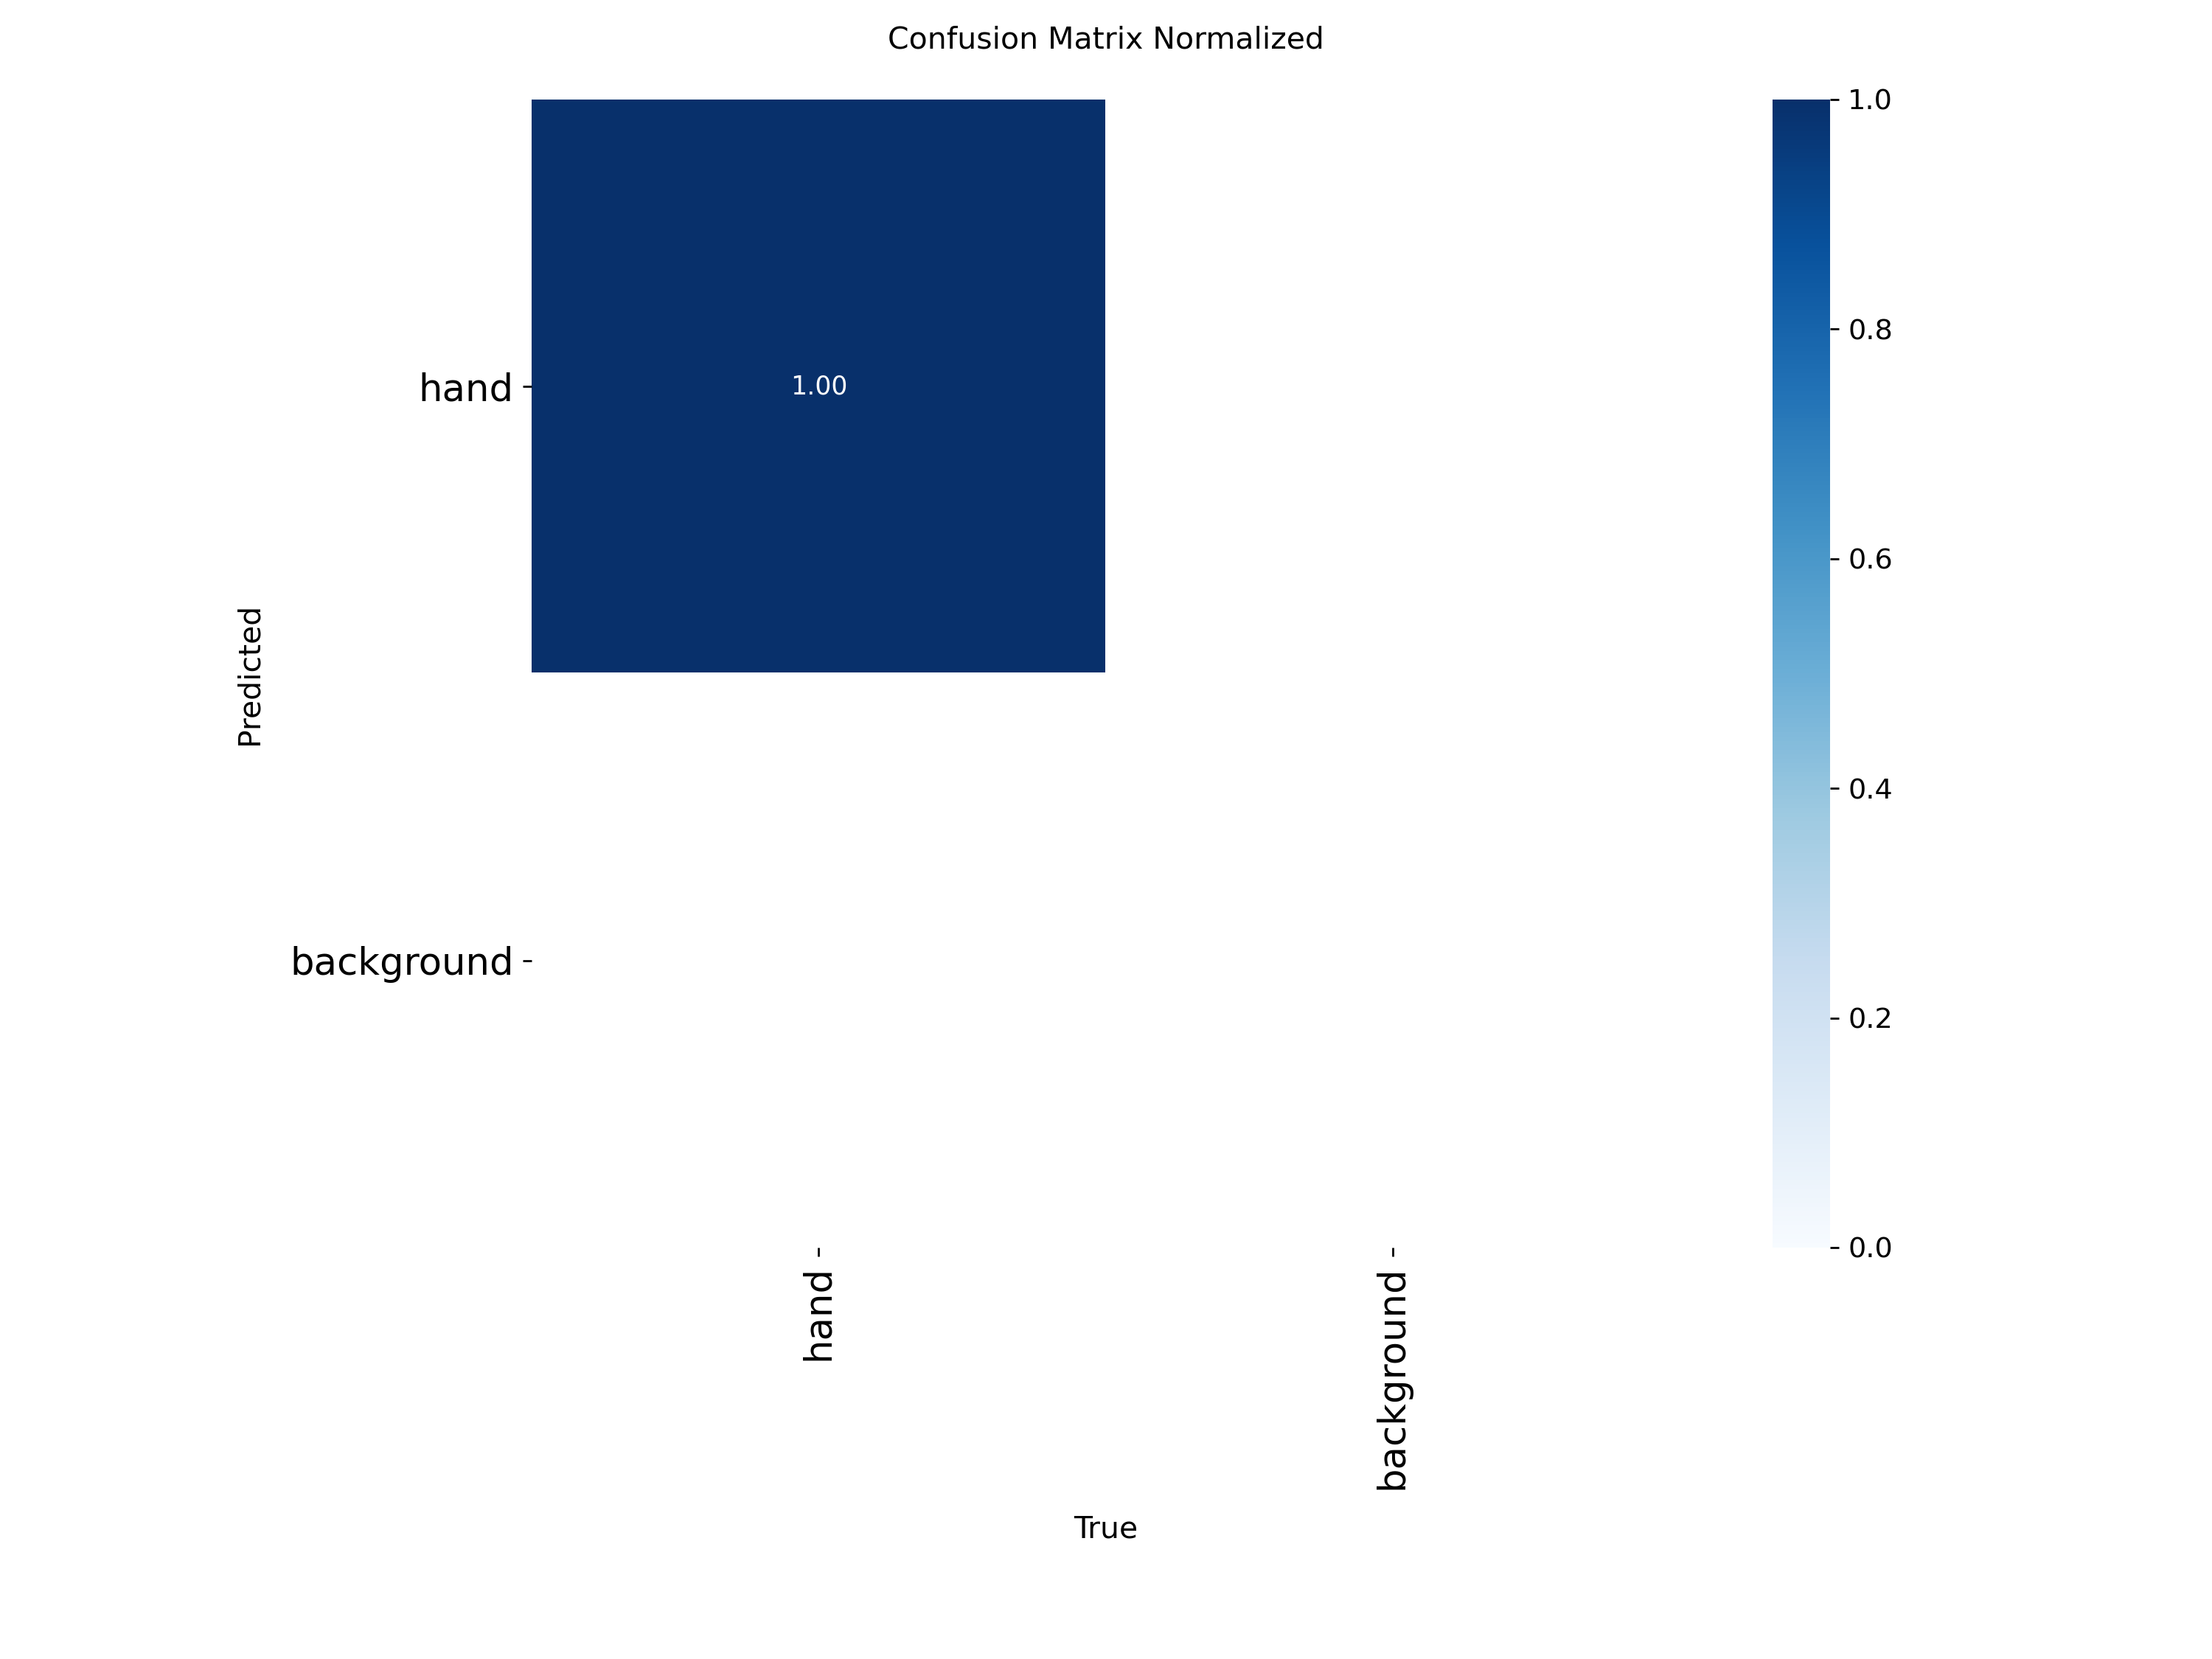

In [24]:
print("Training Results (from training_hand_yolo11):")
for plot in key_plots:
    plot_path = os.path.join(training_dir, plot)
    if os.path.exists(plot_path):
        img = cv2.imread(plot_path)
        if img is not None:
            print(f"Displaying {plot}:")
            cv2_imshow(img)
        else:
            print(f"Failed to read {plot} in {training_dir}")
    else:
        print(f"{plot} not found in {training_dir}")

Display test plots


Test Results (from val_test_metrics):
results.png not found in /content/drive/MyDrive/Hand_Gesture_Project/results/detection_metrics/val_test_metrics
Displaying BoxF1_curve.png:


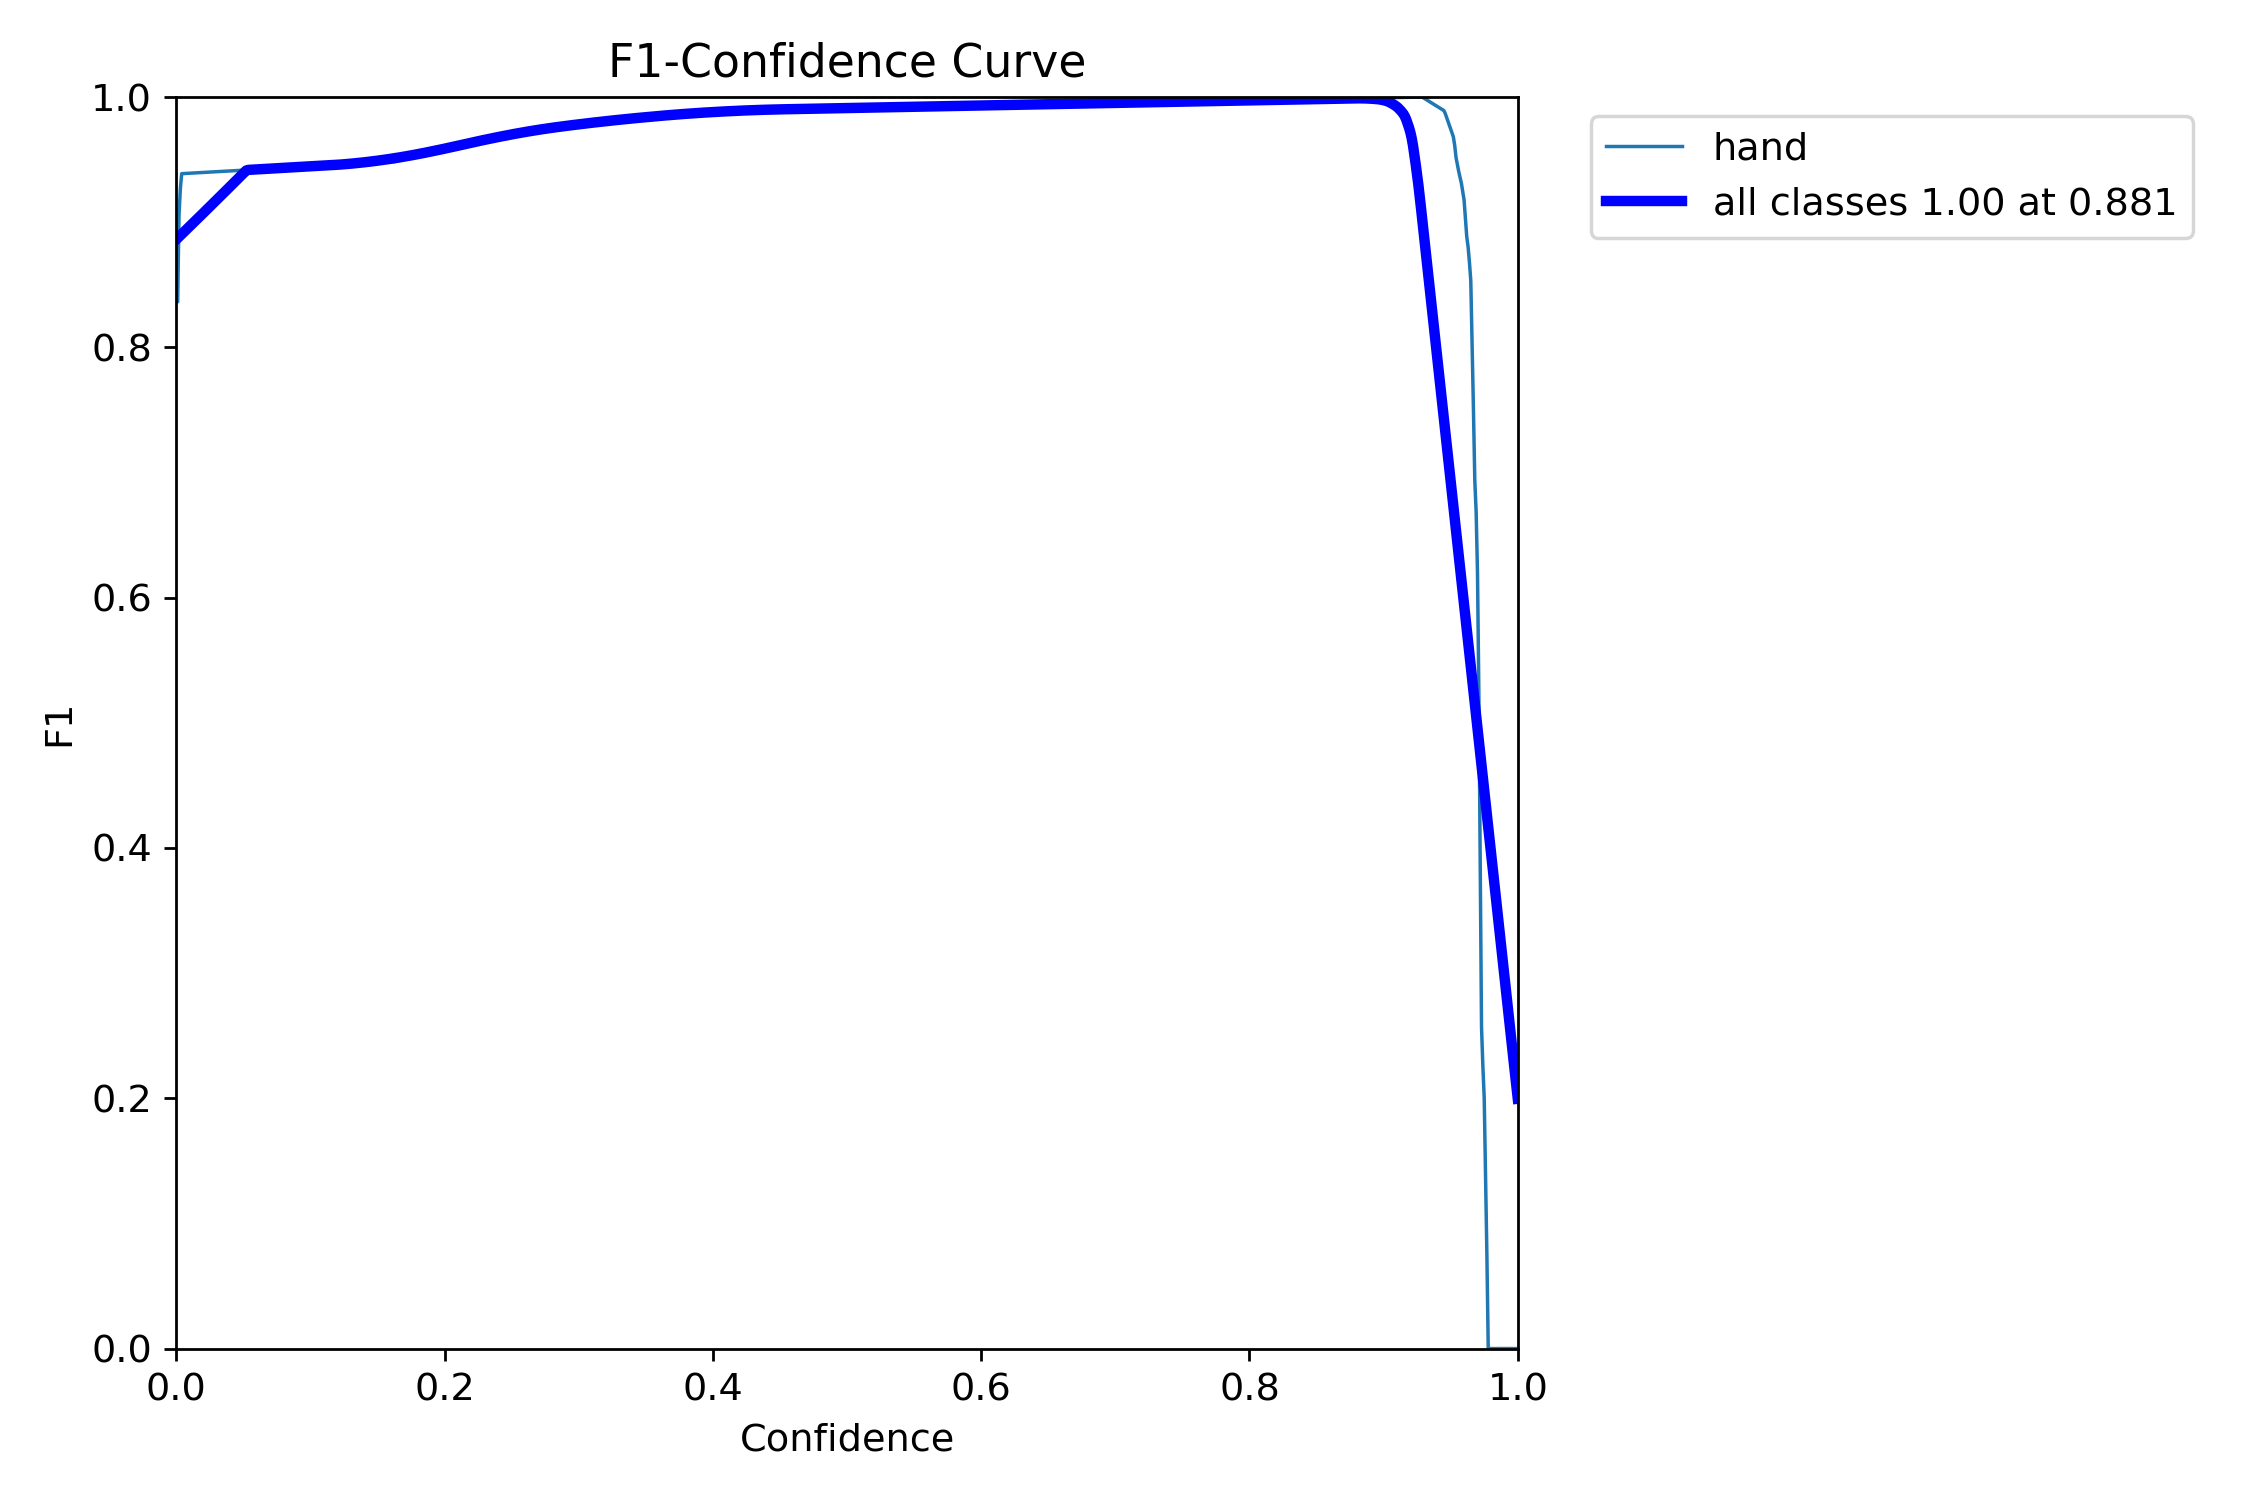

Displaying BoxP_curve.png:


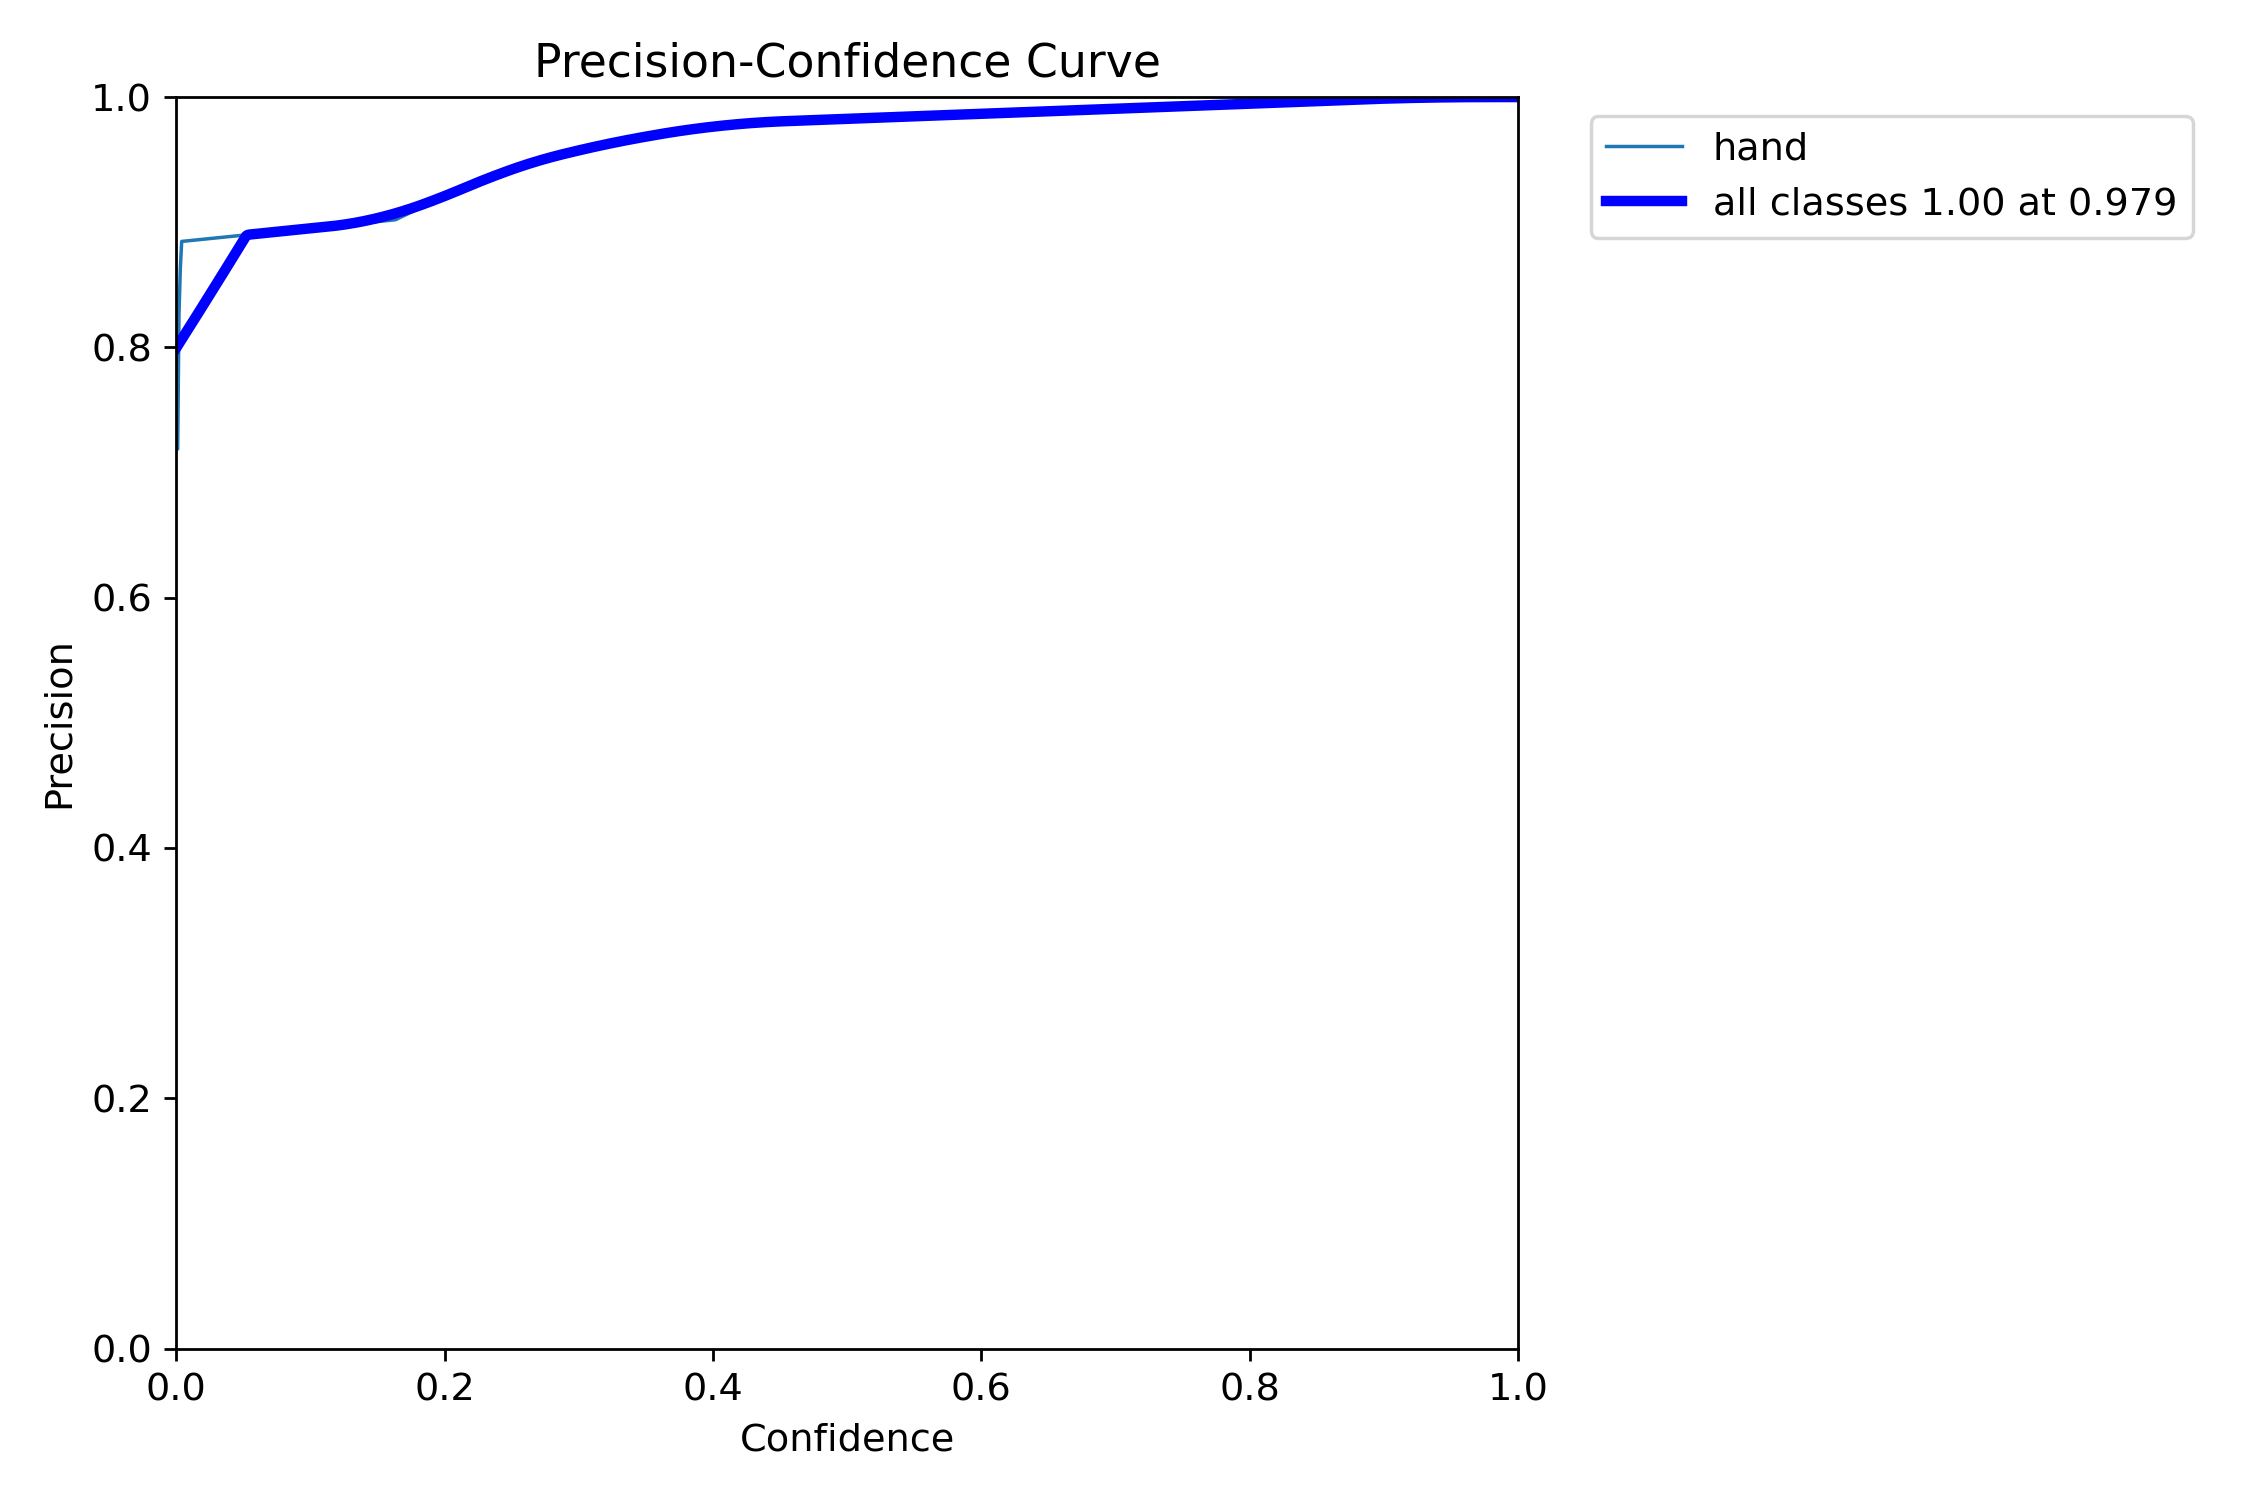

Displaying BoxPR_curve.png:


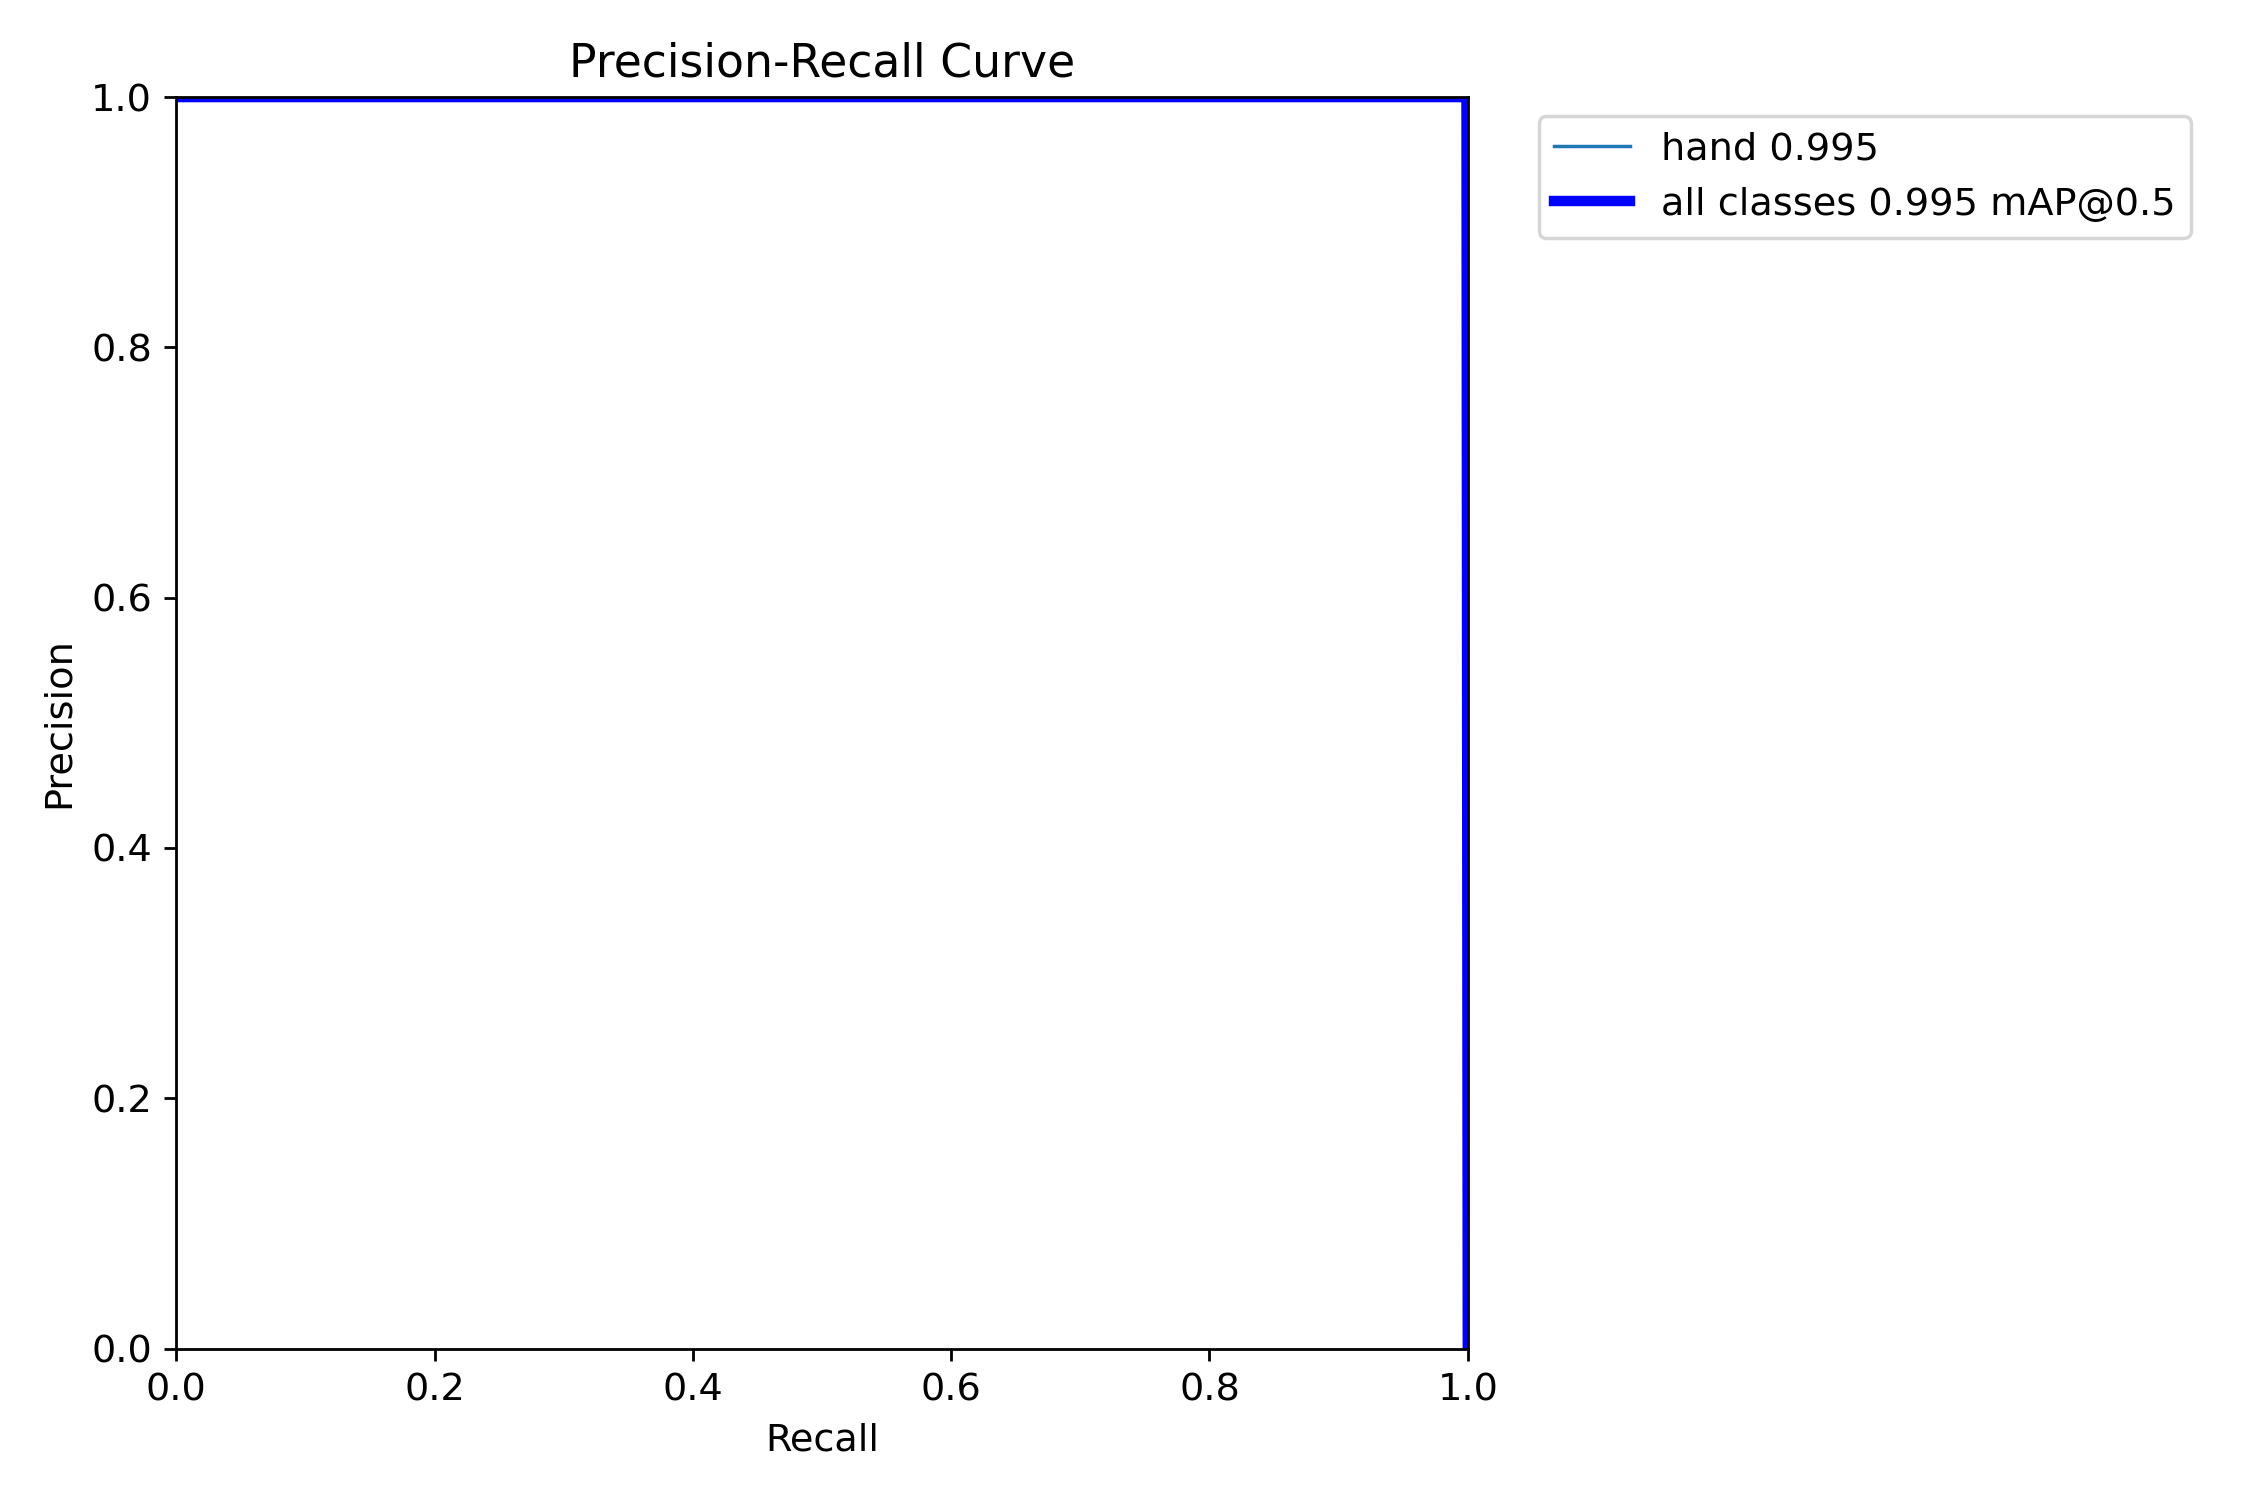

Displaying BoxR_curve.png:


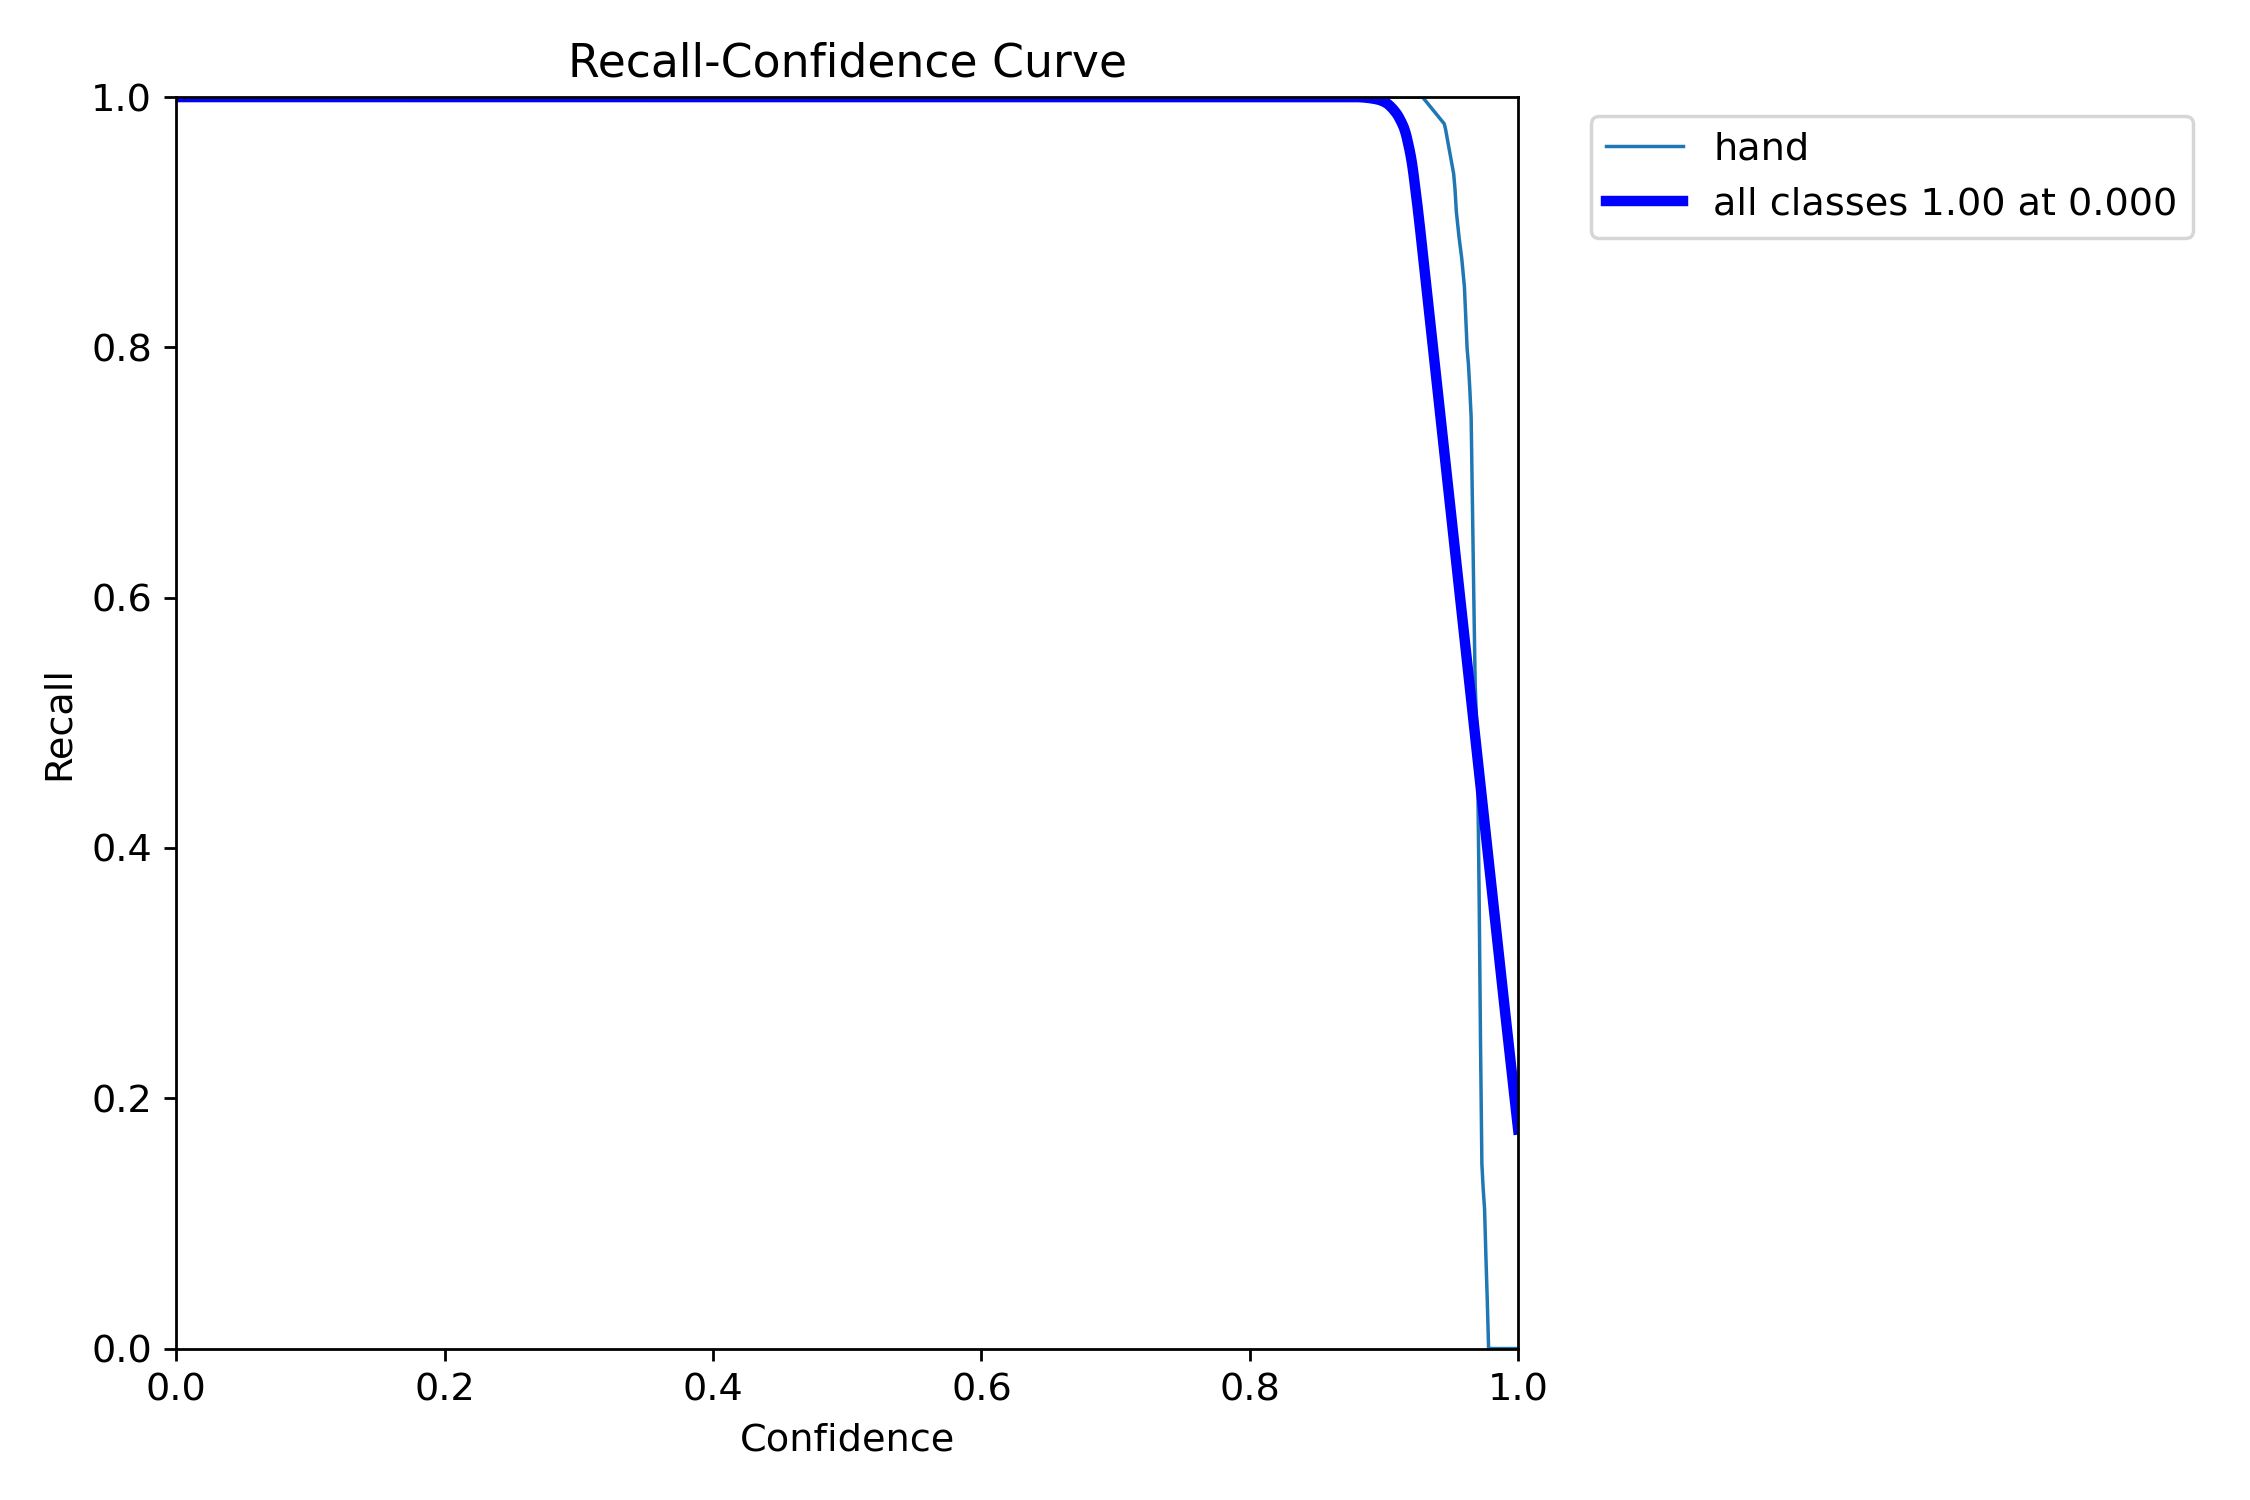

Displaying confusion_matrix.png:


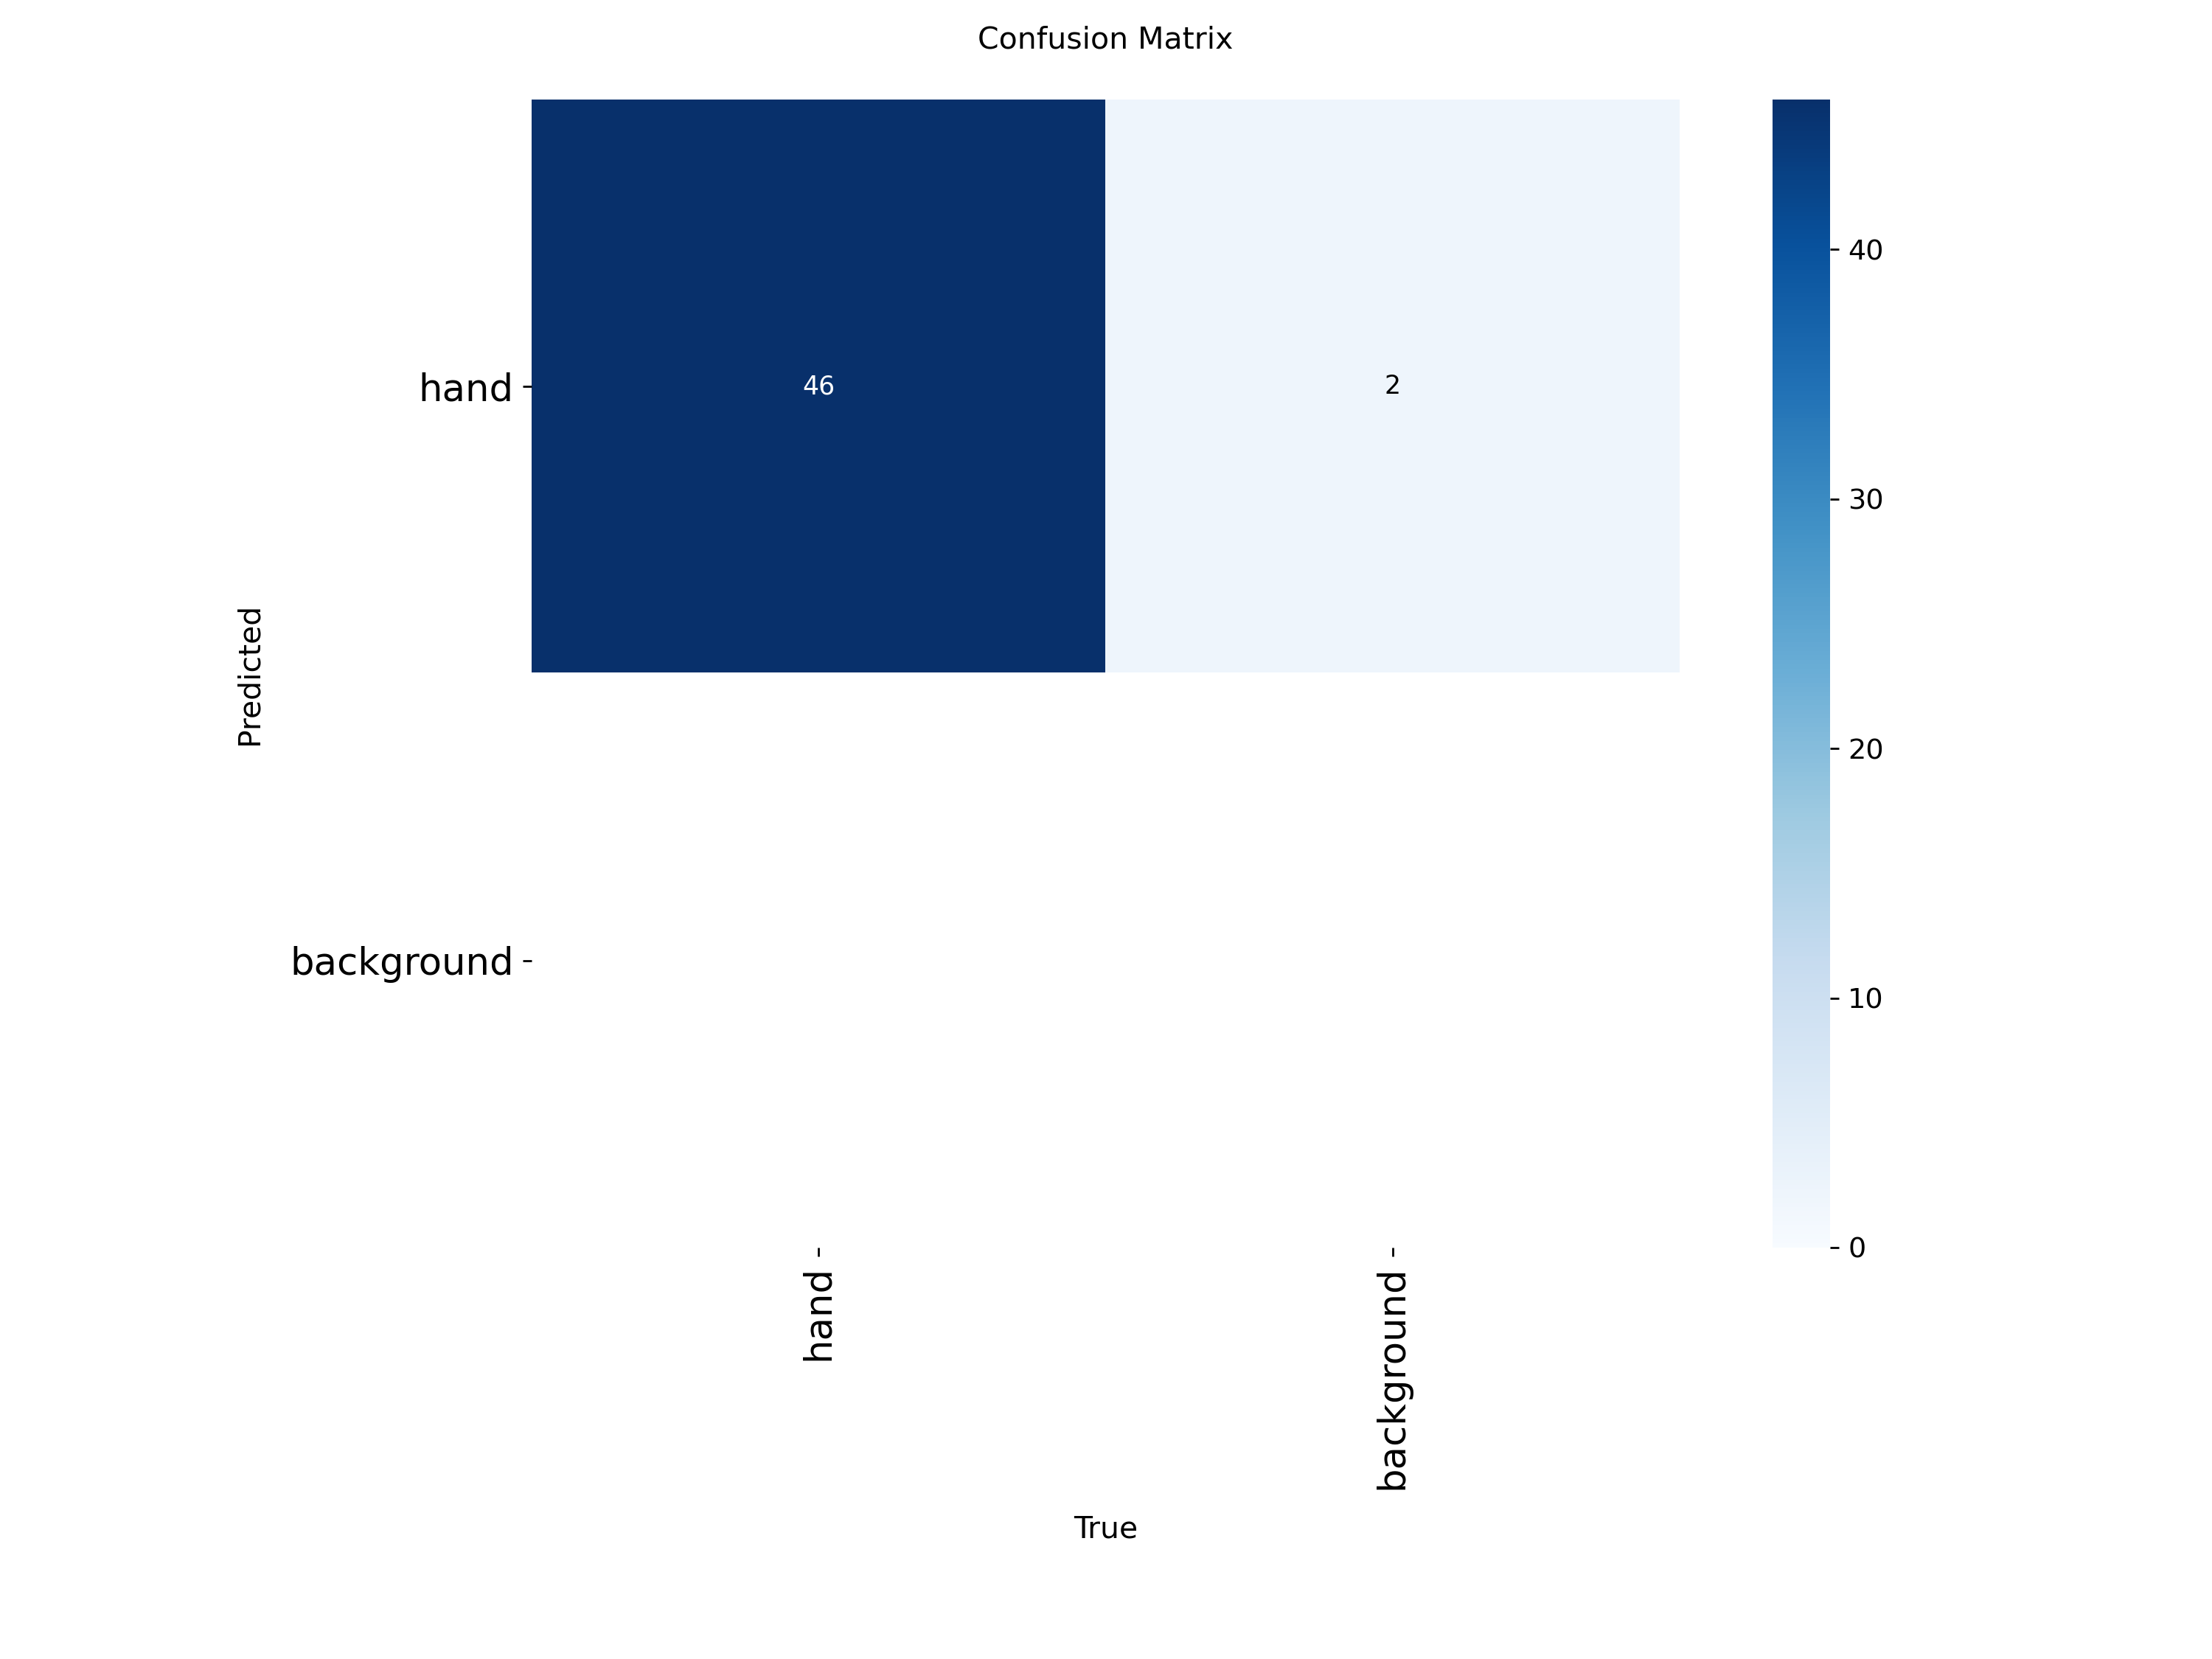

Displaying confusion_matrix_normalized.png:


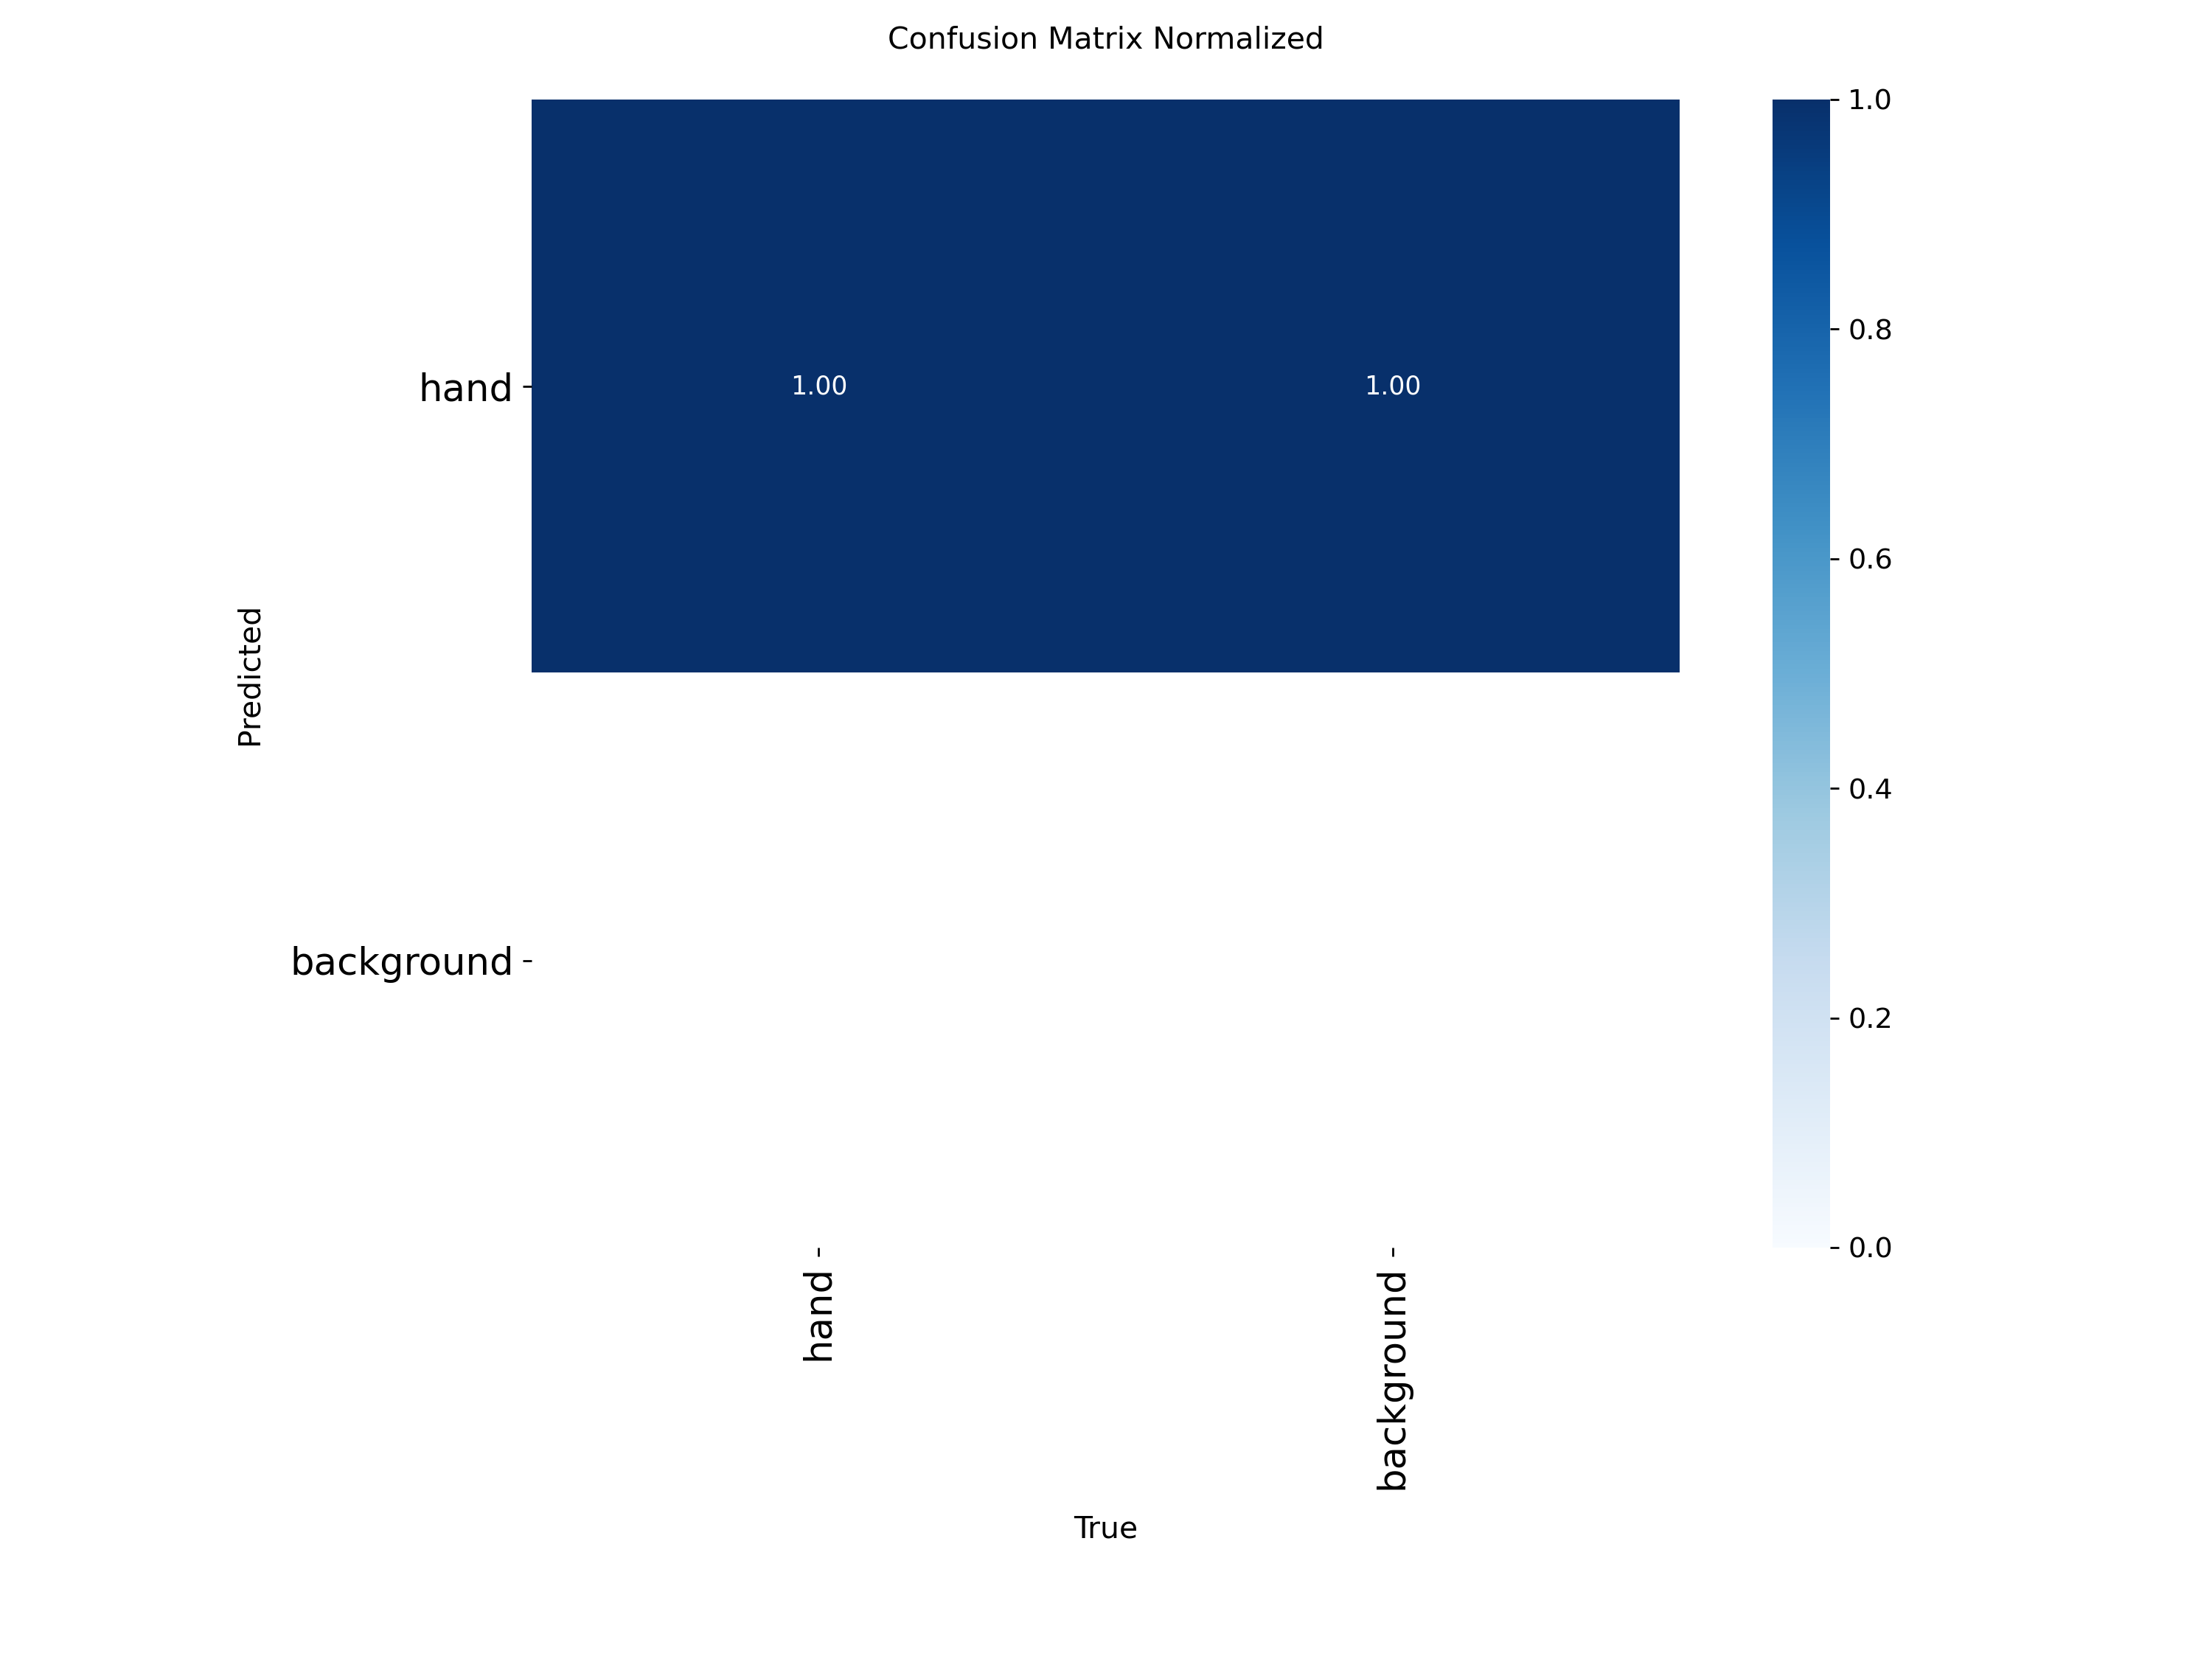

In [25]:
print("\nTest Results (from val_test_metrics):")
for plot in key_plots:
    plot_path = os.path.join(test_dir, plot)
    if os.path.exists(plot_path):
        img = cv2.imread(plot_path)
        if img is not None:
            print(f"Displaying {plot}:")
            cv2_imshow(img)
        else:
            print(f"Failed to read {plot} in {test_dir}")
    else:
        print(f"{plot} not found in {test_dir}")

Display test batch examples (side-by-side labels and predictions for qualitative eval)


Test Batch Examples (labels vs predictions on test dataset):
Displaying val_batch0_labels.jpg (left: ground truth) and val_batch0_pred.jpg (right: predictions):


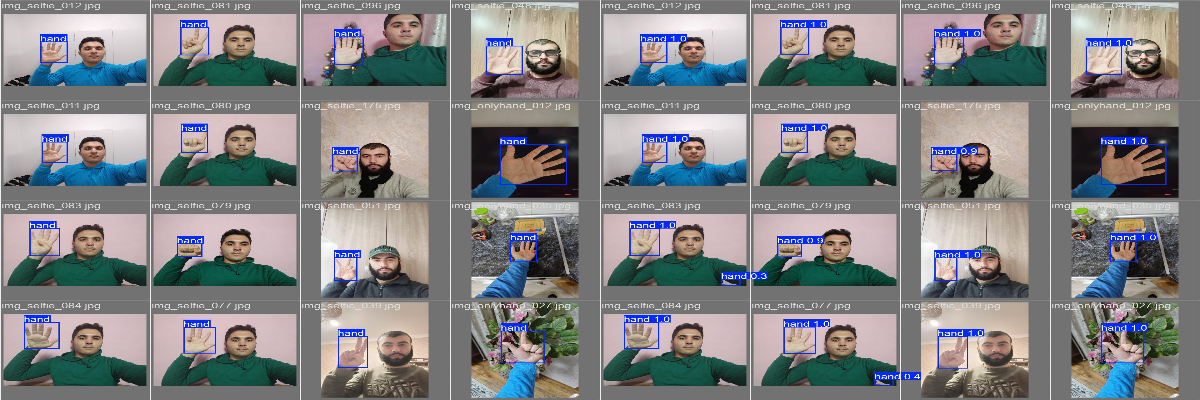

Displaying val_batch1_labels.jpg (left: ground truth) and val_batch1_pred.jpg (right: predictions):


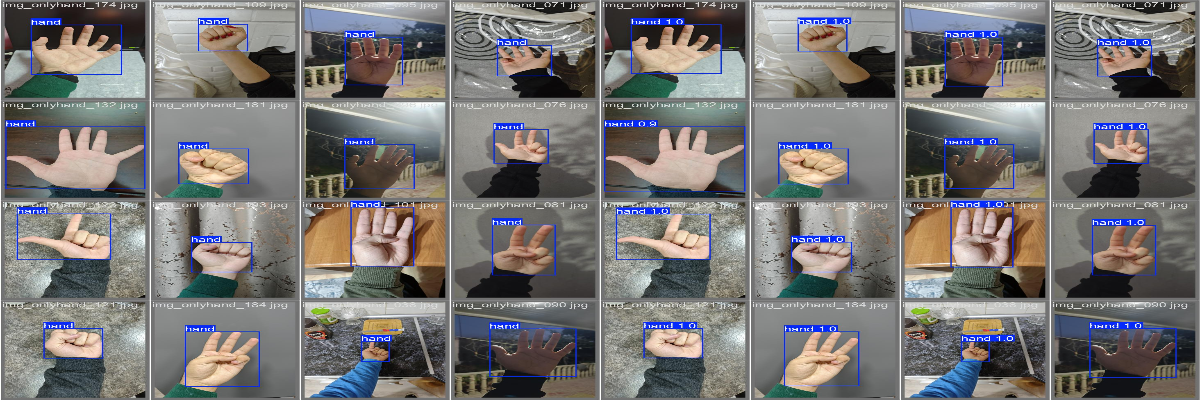

Displaying val_batch2_labels.jpg (left: ground truth) and val_batch2_pred.jpg (right: predictions):


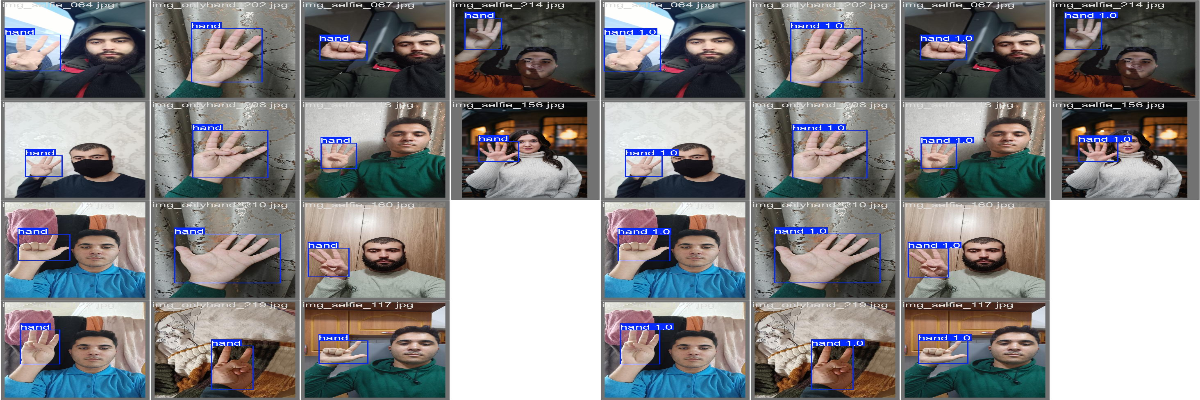

In [26]:
print("\nTest Batch Examples (labels vs predictions on test dataset):")
for i in range(0, len(test_examples), 2):
    labels_path = os.path.join(test_dir, test_examples[i])
    pred_path = os.path.join(test_dir, test_examples[i+1])

    if os.path.exists(labels_path) and os.path.exists(pred_path):
        labels_img = cv2.imread(labels_path)
        pred_img = cv2.imread(pred_path)

        if labels_img is not None and pred_img is not None:
            # Resize for better display (adjust dimensions as needed)
            labels_img = cv2.resize(labels_img, (600, 400))
            pred_img = cv2.resize(pred_img, (600, 400))

            # Concatenate horizontally to show side-by-side
            combined = cv2.hconcat([labels_img, pred_img])
            print(f"Displaying {test_examples[i]} (left: ground truth) and {test_examples[i+1]} (right: predictions):")
            cv2_imshow(combined)
        else:
            print(f"Failed to read one or both images for batch {i//2}")
    else:
        print(f"Files not found for batch {i//2}")

Load and display numerical metrics from results.csv (if it exists in training_dir)

In [27]:
csv_path = os.path.join(training_dir, 'results.csv')
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    display(df.tail(10))  # Last 10 rows for final metrics (e.g., precision, recall, mAP)
else:
    print("results.csv not found")

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
85,86,1527.71,0.34239,0.25628,0.91363,0.99940,1.0,0.995,0.99115,0.17550,0.13660,0.75204,0.000064,0.000064,0.000064
86,87,1545.28,0.34517,0.25499,0.92104,0.99941,1.0,0.995,0.99113,0.17537,0.13371,0.75192,0.000057,0.000057,0.000057
87,88,1562.82,0.35047,0.24597,0.93225,0.99941,1.0,0.995,0.99122,0.17775,0.13214,0.75187,0.000051,0.000051,0.000051
88,89,1579.60,0.34002,0.25866,0.90856,0.99942,1.0,0.995,0.99125,0.17504,0.13076,0.75186,0.000045,0.000045,0.000045
89,90,1596.95,0.32016,0.25327,0.91099,0.99941,1.0,0.995,0.99111,0.17238,0.12941,0.75150,0.000039,0.000039,0.000039
90,91,1620.89,0.18012,0.17277,0.79800,0.99938,1.0,0.995,0.99104,0.17308,0.13353,0.75151,0.000034,0.000034,0.000034
91,92,1638.01,0.17058,0.15785,0.79344,0.99937,1.0,0.995,0.98996,0.17418,0.13585,0.75139,0.000030,0.000030,0.000030
92,93,1655.27,0.17124,0.14992,0.79684,0.99938,1.0,0.995,0.99074,0.17373,0.13545,0.75141,0.000026,0.000026,0.000026
93,94,1674.65,0.16395,0.14689,0.79610,0.99936,1.0,0.995,0.99063,0.17392,0.13362,0.75172,0.000022,0.000022,0.000022
94,95,1691.85,0.15441,0.13937,0.77854,0.99937,1.0,0.995,0.99065,0.17428,0.13261,0.75209,0.000019,0.000019,0.000019
